In [2]:
import pandas as pd
import numpy as np

import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

import squic
from tabulate import tabulate
from SQUIC_functions import *

In [3]:
DATASET = "../datasets/AMLSimData/0_100"

accounts = pd.read_csv(f'{DATASET}/accounts.csv')
transactions = pd.read_csv(f'{DATASET}/transactions.csv')

In [4]:
# Create root
balances = {}

# Take users data from account.csv
for _, row in accounts.iterrows():
    acc_id = row["ACCOUNT_ID"] # User id
    open_date = 0
    initial_balance = round(float(row["INIT_BALANCE"]), 2)

    balances[acc_id] = [{"date": open_date,
                         "balance": initial_balance
                        }]
    
    if acc_id == 0: # Check
        print("first user must be 0 => ",str(acc_id))
        print("user 0 initial deposit must be 184.44 => ", initial_balance)

first user must be 0 =>  0
user 0 initial deposit must be 184.44 =>  184.44


In [5]:
# Apply transactions to users' balances
transactions.sort_values(by="TX_ID")

# Track the last balance for each account
current_balances = {acct_id: balances[acct_id][0]["balance"] for acct_id in balances}

for i, (_, row) in enumerate(transactions.iterrows()):
    orig_acct = row["SENDER_ACCOUNT_ID"]
    bene_acct = row["RECEIVER_ACCOUNT_ID"]
    amount = row["TX_AMOUNT"]
    tx_type = row['TX_TYPE']
    date = row["TIMESTAMP"]

    # if i == 0:
    #     print("first transaction must be from 6456 to 9069 => ", orig_acct, bene_acct)
    # if i == 1323233: # check that read till the last transaction
    #     print("\nlast transaction must be from 545 to 2724 => ", orig_acct, bene_acct)

    if orig_acct in balances: # check that sender has a deposit
        last_balance = balances[orig_acct][-1]["balance"] # read balance from balances
        if tx_type in ['TRANSFER', 'WITHDRAWAL']: # all TRANSFER in the csv
            new_balance = last_balance - amount
        # elif tx_type == 'DEPOSIT':
        #    new_balance = last_balance + amount

        balances[orig_acct].append({"date": date, "balance": round(new_balance, 2)})
        # if orig_acct == 1 and date == 1:
        #     print()
        #     print(row['TX_ID'])
        #     print(f"on date {date} user {orig_acct} send to {bene_acct} {amount} dollars")
        #     print(f"user {orig_acct} balance goes from {last_balance} to {new_balance}")
        #     print(balances[orig_acct])
            
    
    if bene_acct in balances: # check that receiver has a deposit
        last_balance = balances[bene_acct][-1]["balance"]
        if tx_type in ['TRANSFER', 'DEPOSIT']:
            new_balance = last_balance + amount
        # elif tx_type == 'WITHDRAWAL':
        #     new_balance = last_balance - amount

        balances[bene_acct].append({"date": date, "balance": round(new_balance, 2)})
        # if bene_acct == 0:
        #     print()
        #     print(row['TX_ID'])
        #     print(f"on date {date} user {orig_acct} send to {bene_acct} {amount} dollars")
        #     print(f"user {bene_acct} balance goes from {last_balance} to {new_balance}")
        #     print(balances[bene_acct])
            

In [6]:
len(balances)

100

In [7]:
for i, (acct_id, account_data) in enumerate(balances.items()):
    if i < 1:
        print(acct_id)
        print(account_data)
        break

0
[{'date': 0, 'balance': 184.44}, {'date': 2, 'balance': 253.63}, {'date': 3, 'balance': 322.82}, {'date': 7, 'balance': 374.37}, {'date': 13, 'balance': 443.56}, {'date': 16, 'balance': 351.34}, {'date': 16, 'balance': 259.12}, {'date': 18, 'balance': 310.67}, {'date': 23, 'balance': 379.86}, {'date': 26, 'balance': 287.64}, {'date': 26, 'balance': 195.42}, {'date': 27, 'balance': 103.2}, {'date': 27, 'balance': 10.98}, {'date': 27, 'balance': 62.53}, {'date': 29, 'balance': -29.69}, {'date': 29, 'balance': -121.91}, {'date': 30, 'balance': -52.72}, {'date': 31, 'balance': 16.47}, {'date': 37, 'balance': -75.75}, {'date': 37, 'balance': -167.97}, {'date': 38, 'balance': -116.42}, {'date': 49, 'balance': -47.23}, {'date': 49, 'balance': -139.45}, {'date': 49, 'balance': -231.67}, {'date': 51, 'balance': -162.48}, {'date': 53, 'balance': -93.29}, {'date': 57, 'balance': -185.51}, {'date': 57, 'balance': -277.73}, {'date': 58, 'balance': -226.18}, {'date': 68, 'balance': -318.4}, {'date

In [8]:
result = []

for date in sorted(set(transactions["TIMESTAMP"])):
    daily_balances = {
        "date": date,
        "balances": {
            str(user): {
                "balance": next((entry["balance"] for entry in reversed(b) if entry["date"] <= date), b[0]["balance"])
            } for user, b in balances.items()}
    }
    result.append(daily_balances)

In [9]:
df = pd.DataFrame(result)

# Unpack 'balances' into separate columns for each user
df = df.join(pd.DataFrame(df['balances'].tolist()))

df.drop('balances', axis=1, inplace=True)
df.set_index('date', inplace=True)
df.drop('_id', axis=1, inplace=True, errors='ignore')

for col in df.columns:
    df[col] = df[col].apply(lambda x: x['balance'] if isinstance(x, dict) else x)

In [10]:
#df = pd.DataFrame([{**entry["balances"], "date": entry["date"]} for entry in data])

#print(df.shape) # must be (720, 1447)
#print(df.head())

#      | id1 | id2 | ... | id1446
# day1 |   
# day2 |        balances
# ...

In [11]:
df

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
date,,,,,,,,,,,,,,,,,,,,,
0,184.44,175.80,142.06,125.89,151.13,140.49,178.38,130.33,147.66,158.34,...,411.76,331.00,340.34,426.02,463.36,411.81,437.84,238.28,386.67,297.29
1,184.44,0.00,142.06,125.89,182.79,140.49,194.34,130.33,163.62,31.70,...,411.76,346.06,356.30,426.02,463.36,411.81,452.90,238.28,386.67,297.29
2,253.63,12.38,142.06,138.27,195.17,217.43,194.34,130.33,163.62,92.89,...,485.33,425.57,356.30,426.02,475.74,578.08,452.90,307.47,416.62,12.55
3,322.82,12.38,142.06,138.27,195.17,217.43,264.42,164.84,163.62,92.89,...,517.69,425.57,356.30,461.13,475.74,647.27,452.90,406.85,551.40,147.33
4,322.82,22.28,198.79,138.27,283.92,76.94,264.42,202.88,163.62,92.89,...,758.87,493.80,137.97,478.19,592.32,702.29,165.99,637.58,681.07,272.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,-1312.03,-3998.92,-1015.09,-929.73,759.18,175.20,-68.40,131.37,-953.47,-445.13,...,6129.84,2741.40,6605.25,3671.52,1318.73,5914.94,7758.35,9444.49,11741.15,11217.91
196,-1312.03,-3998.92,-1157.14,-929.73,759.18,175.20,-68.40,131.37,-953.47,-445.13,...,6129.84,2754.61,6605.25,3709.68,1318.73,5932.86,7897.52,9457.70,11788.50,11285.84
197,-1312.03,-3998.92,-1299.19,-929.73,639.73,175.20,-68.40,131.37,-953.47,-571.77,...,5823.71,2800.86,6641.93,3833.55,1418.36,5990.27,8095.31,9607.42,11959.72,11468.65


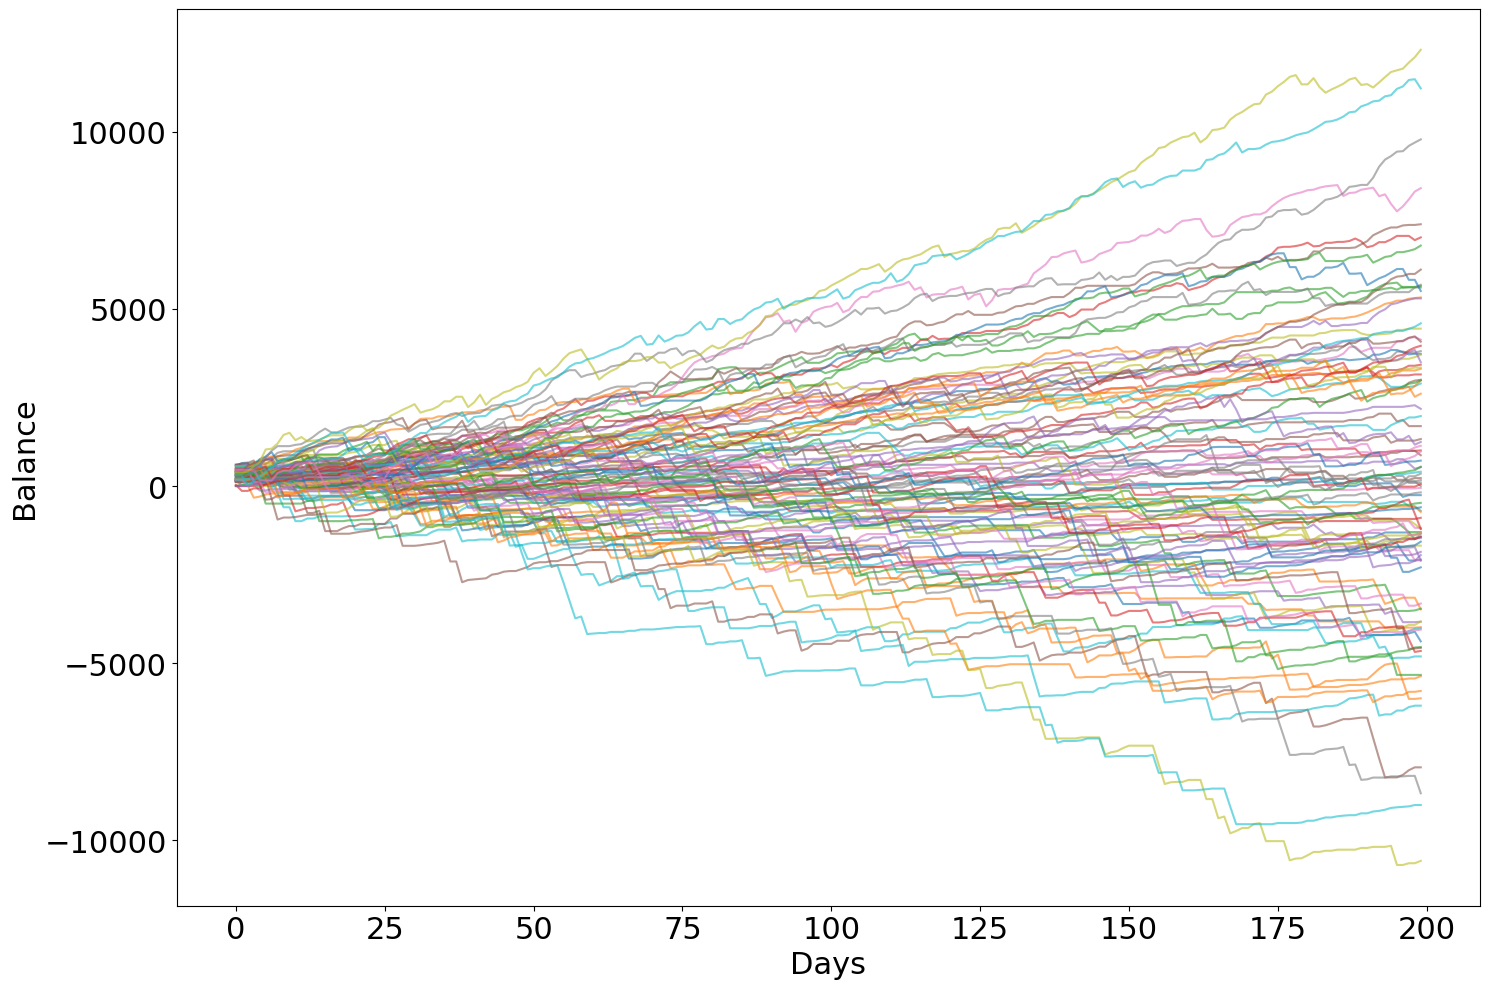

In [12]:
# Plot the balance evolution for all users (columns) as separate lines
# plt.figure(figsize=(15,10), dpi= 300)
plt.figure(figsize=(15,10))

# Plot each column (account balance) as a line
for user in df.columns:
    plt.plot(df.index, df[user], label=f"User {user}", alpha=0.6)

# Add title and labels
# plt.title("Balance Evolution of Users Over Time")
plt.xlabel("Days", fontsize=22)
plt.ylabel("Balance", fontsize=22)

# Rotate x-axis labels for better visibility
#plt.xticks(rotation=45)
plt.tick_params(axis='x', labelsize=22)
plt.tick_params(axis='y', labelsize=22)

# Add legend to differentiate users
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Display the plot
plt.tight_layout()
plt.show()

# Balance Distribution

### First and last day

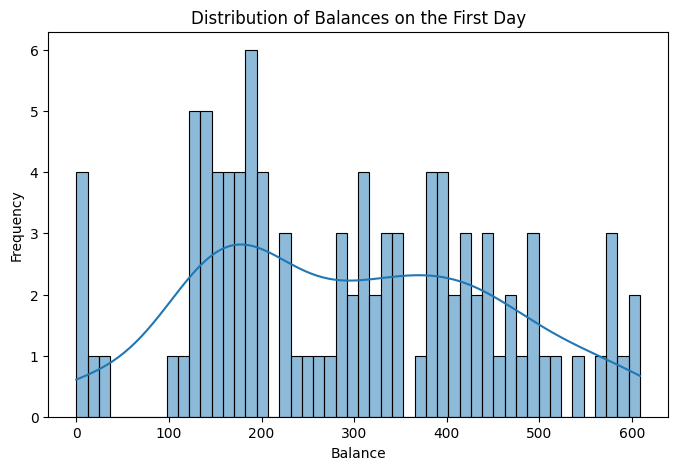

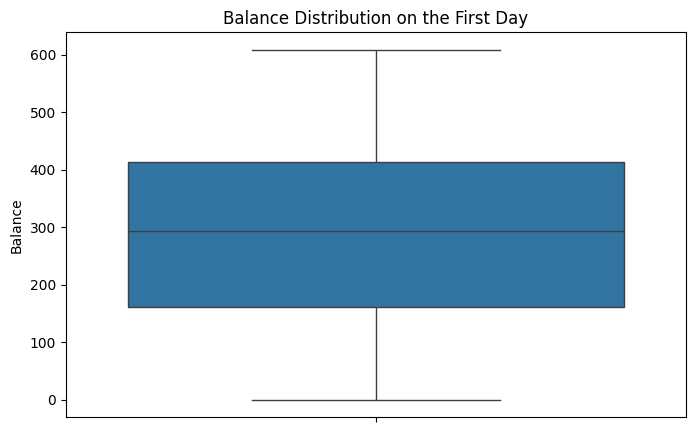

In [13]:
# Select the balances on the first day
first_day_balances = df.iloc[0]

# Plot histogram
plt.figure(figsize=(8, 5))
sns.histplot(first_day_balances, bins=50, kde=True)
plt.xlabel("Balance")
plt.ylabel("Frequency")
plt.title("Distribution of Balances on the First Day")
plt.show()

# Plot box plot
plt.figure(figsize=(8, 5))
sns.boxplot(y=first_day_balances)
plt.ylabel("Balance")
plt.title("Balance Distribution on the First Day")
plt.show()

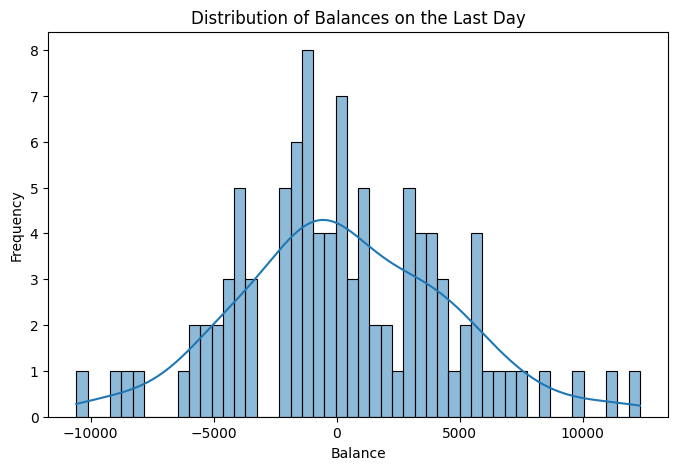

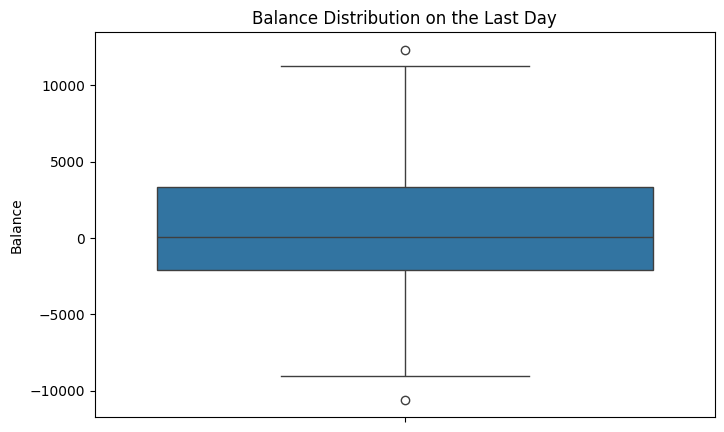

In [14]:
# Select the balances on the first day
last_day_balances = df.iloc[-1]

# Plot histogram
plt.figure(figsize=(8, 5))
sns.histplot(last_day_balances, bins=50, kde=True)
plt.xlabel("Balance")
plt.ylabel("Frequency")
plt.title("Distribution of Balances on the Last Day")
plt.show()

# Plot box plot
plt.figure(figsize=(8, 5))
sns.boxplot(y=last_day_balances)
plt.ylabel("Balance")
plt.title("Balance Distribution on the Last Day")
plt.show()

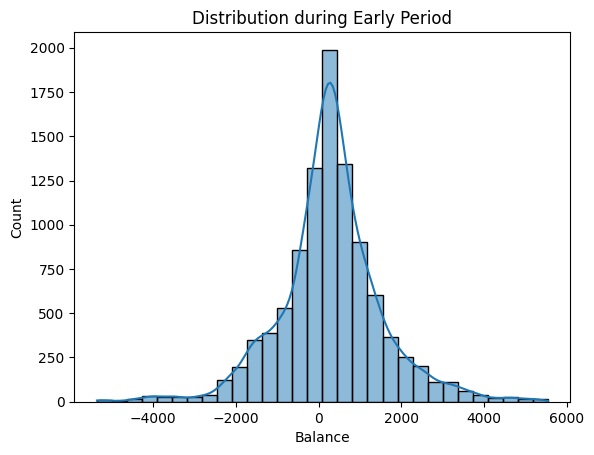

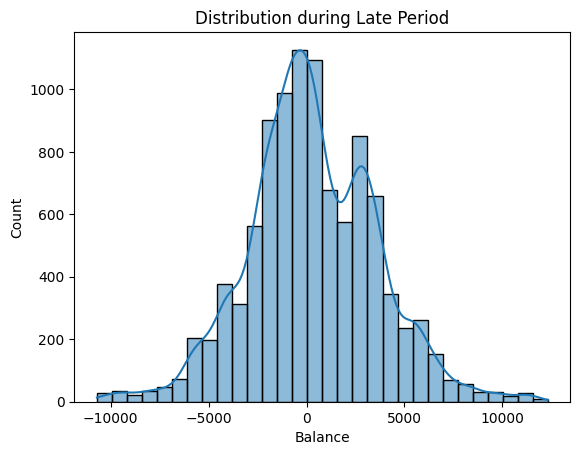

In [15]:
# Split the DataFrame into two parts
early_period = df.iloc[:int(0.5 * len(df))]
late_period  = df.iloc[int(0.5 * len(df)):]

# Plot distribution for early days (aggregated over users and days)
sns.histplot(early_period.values.flatten(), bins=30, kde=True)
plt.title("Distribution during Early Period")
plt.xlabel("Balance")
plt.show()

# Plot distribution for late days
sns.histplot(late_period.values.flatten(), bins=30, kde=True)
plt.title("Distribution during Late Period")
plt.xlabel("Balance")
plt.show()

### Total Distribution

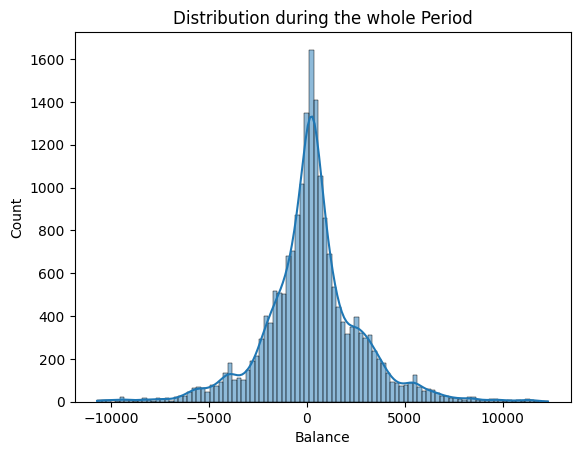

In [16]:
values_df = df.values.flatten()
# Plot distribution for all the days (aggregated over users and days)
sns.histplot(values_df, bins=100, kde=True)
plt.title("Distribution during the whole Period")
plt.xlabel("Balance")
plt.show()

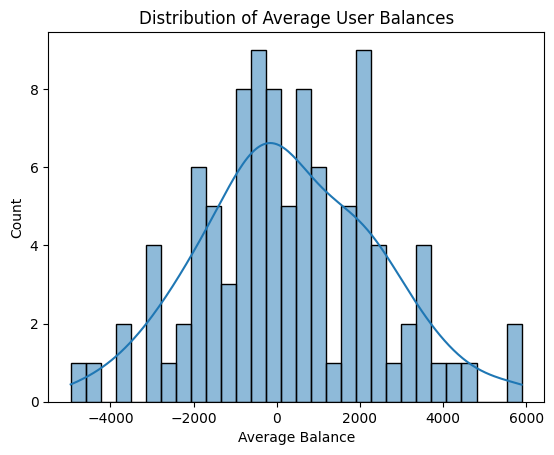

In [17]:
# Compute the mean balance per user over all days
user_means = df.mean(axis=0)

sns.histplot(user_means, bins=30, kde=True)
plt.title("Distribution of Average User Balances")
plt.xlabel("Average Balance")
plt.show()

# Squic

In [18]:
df.T

date,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
0,184.44,184.44,253.63,322.82,322.82,322.82,322.82,374.37,374.37,374.37,...,-1450.41,-1450.41,-1381.22,-1312.03,-1312.03,-1312.03,-1312.03,-1312.03,-1496.47,-1427.28
1,175.80,0.00,12.38,12.38,22.28,22.28,32.18,32.18,32.18,32.18,...,-3823.12,-3823.12,-3823.12,-3998.92,-3998.92,-3998.92,-3998.92,-3998.92,-3998.92,-3986.54
2,142.06,142.06,142.06,142.06,198.79,56.74,66.64,66.64,-28.58,-28.58,...,-919.87,-919.87,-919.87,-919.87,-919.87,-1015.09,-1157.14,-1299.19,-1299.19,-1299.19
3,125.89,125.89,138.27,138.27,138.27,138.27,138.27,138.27,178.23,218.19,...,-989.31,-929.73,-929.73,-929.73,-929.73,-929.73,-929.73,-929.73,-929.73,-897.73
4,151.13,182.79,195.17,195.17,283.92,204.50,204.50,204.50,204.50,236.16,...,638.77,687.49,687.49,687.49,687.49,759.18,759.18,639.73,488.62,532.66
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,411.81,411.81,578.08,647.27,702.29,738.97,738.97,839.29,855.04,870.79,...,5302.29,5467.55,5565.16,5685.16,5838.99,5914.94,5932.86,5990.27,5990.27,6112.25
96,437.84,452.90,452.90,452.90,165.99,159.13,159.13,369.29,433.40,433.40,...,8397.31,8426.50,8186.50,8237.63,7969.31,7758.35,7897.52,8095.31,8317.07,8411.27
97,238.28,238.28,307.47,406.85,637.58,807.53,997.13,1126.93,1126.93,1126.93,...,8504.86,8706.56,9016.88,9218.89,9317.82,9444.49,9457.70,9607.42,9701.23,9790.04
98,386.67,386.67,416.62,551.40,681.07,1032.70,1054.83,1201.22,1443.05,1505.01,...,11352.51,11255.45,11399.45,11549.06,11693.80,11741.15,11788.50,11959.72,12111.11,12321.77


In [19]:
ROWS = len(df.iloc[0])

In [20]:
l = [1e-1, 1e-2, 1e-3, 1e-4, 1e-5]

## Squic DF

In [21]:
Y = df.T.to_numpy()  # Transpose to get shape (users, days)

In [22]:
rho_dict = {}

not returning good results, one big block

In [23]:
import time

In [24]:
l = [1e5, 2e5, 3e5, 4e5, 5e5, 6e5, 7e5, 8e5, 9e5, 10e5, 11e5, 12e5, 13e5, 14e5, 15e5, 16e5, 17e5, 18e5, 19e5, 20e5]

100000.0
----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e+05 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=1.54e-03 nnz(S)/p=7.83e+01
* iter=1 time=4.73e-03 obj=9.12e+07 |delta(obj)|/obj=9.29e-01 nnz(X,L,W)/p=[7.83e+01 4.18e+01 1.02e+00] lns_iter=29 
* iter=2 time=7.51e-03 obj=4.89e+07 |delta(obj)|/obj=8.67e-01 nnz(X,L,W)/p=[7.83e+01 4.18e+01 6.11e+01] lns_iter=30 
* iter=3 time=2.27e-02 obj=3.32e+07 |del

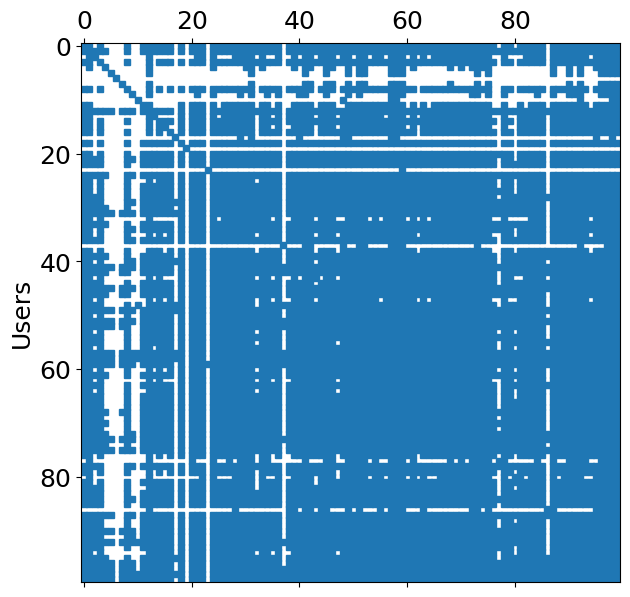

nnz = 7828
nnz/row = 78.28
200000.0
----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      2.000000e+05 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=4.14e-04 nnz(S)/p=6.89e+01
* iter=1 time=2.63e-03 obj=1.08e+08 |delta(obj)|/obj=6.36e-01 nnz(X,L,W)/p=[6.89e+01 3.78e+01 1.00e+00] lns_iter=29 
* iter=2 time=4.17e-03 obj=6.73e+07 |delta(obj)|/obj=5.98e-01 nnz(X,L,W)/p=[6.89e+01 3.78e+01 5.96e+01] lns_iter=30 
* iter=3 time

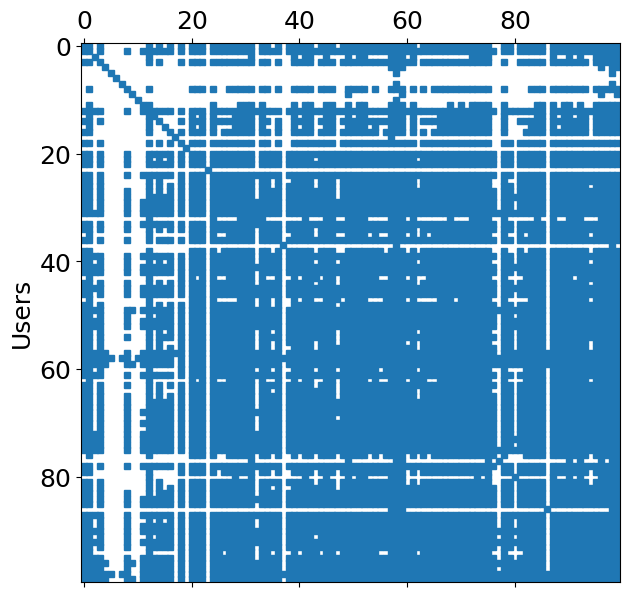

nnz = 6894
nnz/row = 68.94
300000.0
----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      3.000000e+05 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=3.72e-04 nnz(S)/p=6.24e+01
* iter=1 time=2.51e-03 obj=1.23e+08 |delta(obj)|/obj=4.25e-01 nnz(X,L,W)/p=[6.24e+01 3.43e+01 1.00e+00] lns_iter=29 
* iter=2 time=3.90e-03 obj=8.58e+07 |delta(obj)|/obj=4.40e-01 nnz(X,L,W)/p=[6.24e+01 3.43e+01 5.73e+01] lns_iter=30 
* iter=3 time

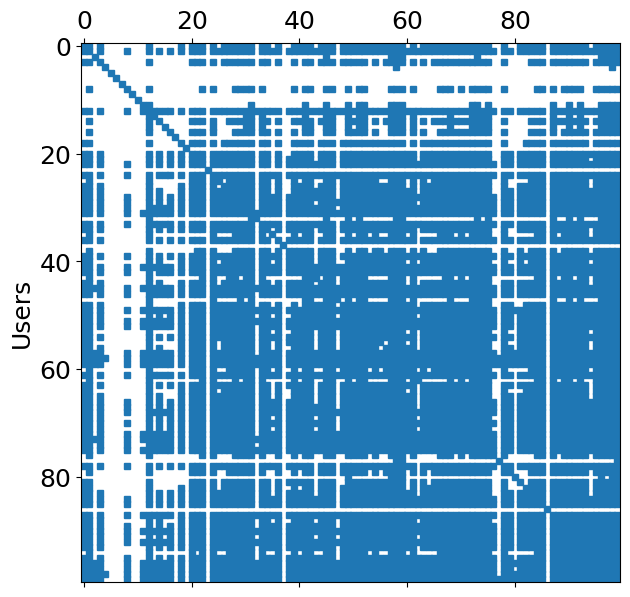

nnz = 6244
nnz/row = 62.44
400000.0
----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      4.000000e+05 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=3.89e-04 nnz(S)/p=5.66e+01
* iter=1 time=2.51e-03 obj=1.39e+08 |delta(obj)|/obj=2.67e-01 nnz(X,L,W)/p=[5.66e+01 3.11e+01 1.00e+00] lns_iter=29 
* iter=2 time=3.58e-03 obj=1.04e+08 |delta(obj)|/obj=3.41e-01 nnz(X,L,W)/p=[5.66e+01 3.11e+01 5.50e+01] lns_iter=30 
* iter=3 time

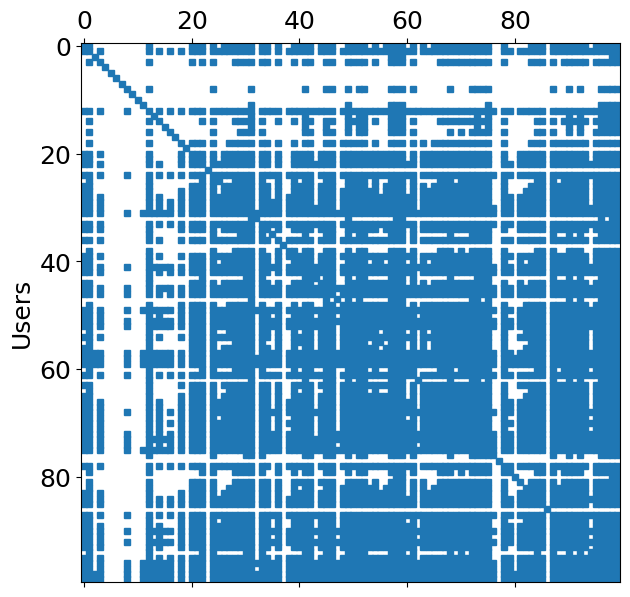

nnz = 5658
nnz/row = 56.58
500000.0
----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      5.000000e+05 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=3.44e-04 nnz(S)/p=5.18e+01
* iter=1 time=2.34e-03 obj=1.54e+08 |delta(obj)|/obj=1.44e-01 nnz(X,L,W)/p=[5.18e+01 2.85e+01 1.00e+00] lns_iter=29 
* iter=2 time=3.18e-03 obj=8.76e+07 |delta(obj)|/obj=7.56e-01 nnz(X,L,W)/p=[5.18e+01 2.85e+01 7.03e+01] lns_iter=29 
* iter=3 time

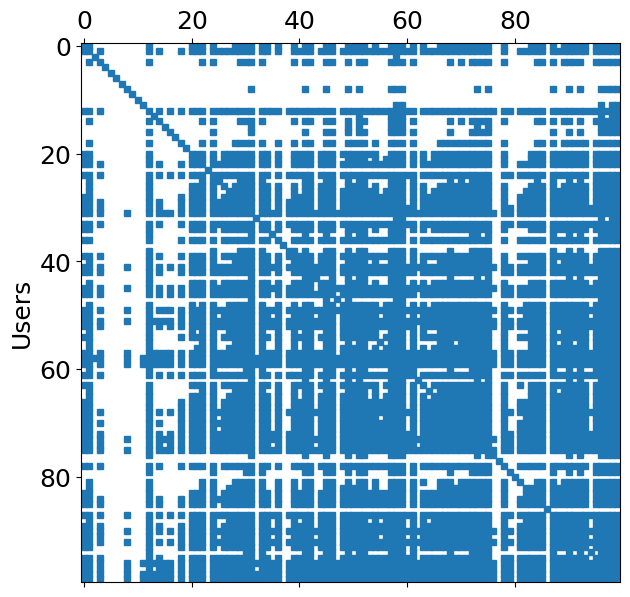

nnz = 5182
nnz/row = 51.82
600000.0
----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      6.000000e+05 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=4.12e-04 nnz(S)/p=4.75e+01
* iter=1 time=5.09e-03 obj=1.01e+08 |delta(obj)|/obj=7.42e-01 nnz(X,L,W)/p=[4.75e+01 2.63e+01 4.76e+01] lns_iter=28 
* iter=2 time=7.08e-03 obj=1.00e+08 |delta(obj)|/obj=7.80e-03 nnz(X,L,W)/p=[4.75e+01 2.63e+01 6.90e+01] lns_iter=22 
* iter=3 time

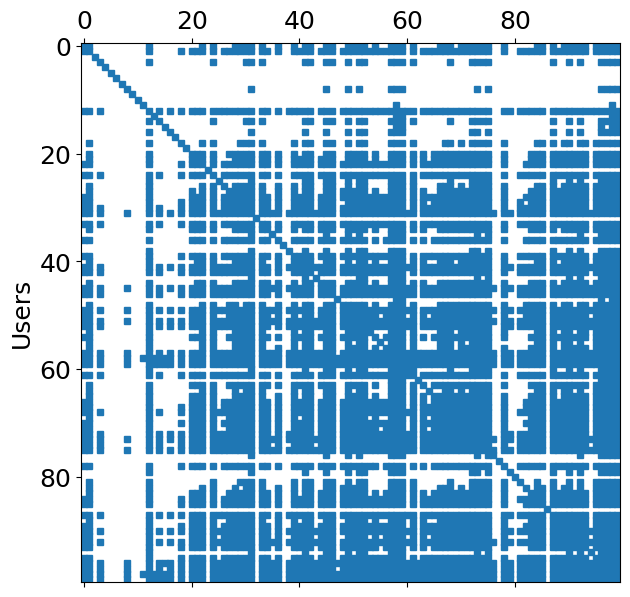

nnz = 4746
nnz/row = 47.46
700000.0
----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      7.000000e+05 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=4.39e-04 nnz(S)/p=4.33e+01
* iter=1 time=1.99e-03 obj=1.20e+08 |delta(obj)|/obj=4.71e-01 nnz(X,L,W)/p=[4.33e+01 2.40e+01 2.67e+01] lns_iter=28 
* iter=2 time=4.89e-03 obj=1.18e+08 |delta(obj)|/obj=1.15e-02 nnz(X,L,W)/p=[4.33e+01 2.40e+01 5.70e+01] lns_iter=28 
* iter=3 time

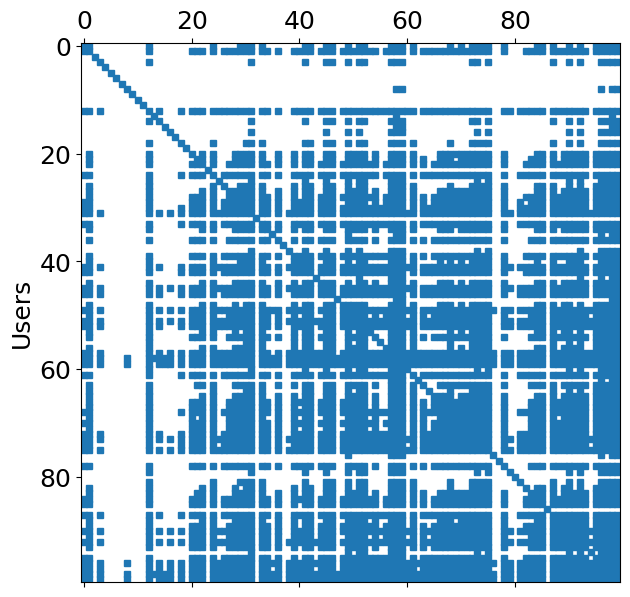

nnz = 4326
nnz/row = 43.26
800000.0
----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      8.000000e+05 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=3.70e-04 nnz(S)/p=3.99e+01
* iter=1 time=2.01e-03 obj=1.38e+08 |delta(obj)|/obj=2.79e-01 nnz(X,L,W)/p=[3.99e+01 2.19e+01 1.58e+01] lns_iter=28 
* iter=2 time=3.88e-03 obj=1.35e+08 |delta(obj)|/obj=2.11e-02 nnz(X,L,W)/p=[3.99e+01 2.19e+01 5.91e+01] lns_iter=28 
* iter=3 time

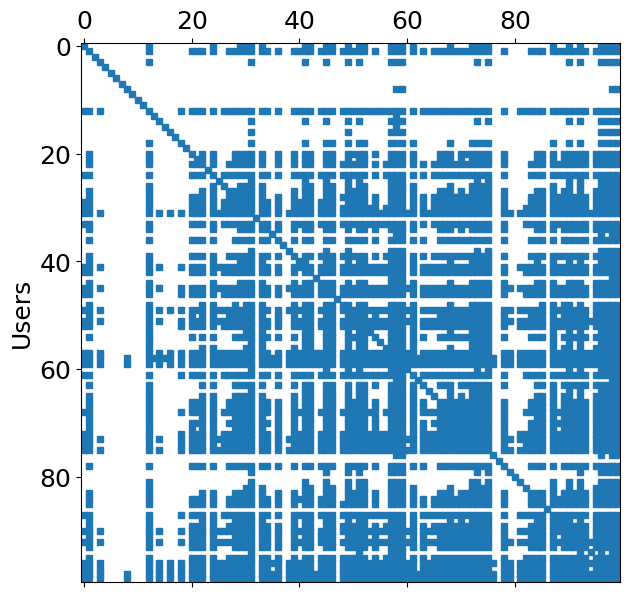

nnz = 3992
nnz/row = 39.92
900000.0
----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.000000e+05 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=3.68e-04 nnz(S)/p=3.65e+01
* iter=1 time=1.85e-03 obj=1.55e+08 |delta(obj)|/obj=1.36e-01 nnz(X,L,W)/p=[3.65e+01 2.02e+01 1.01e+01] lns_iter=28 
* iter=2 time=3.41e-03 obj=1.45e+08 |delta(obj)|/obj=6.60e-02 nnz(X,L,W)/p=[3.65e+01 2.02e+01 6.25e+01] lns_iter=27 
* iter=3 time

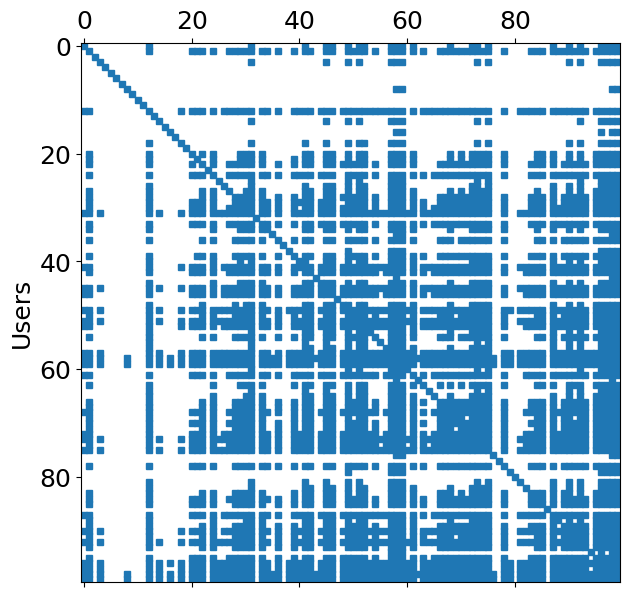

nnz = 3646
nnz/row = 36.46
1000000.0
----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e+06 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=4.20e-04 nnz(S)/p=3.37e+01
* iter=1 time=1.71e-03 obj=1.72e+08 |delta(obj)|/obj=2.47e-02 nnz(X,L,W)/p=[3.37e+01 1.85e+01 7.04e+00] lns_iter=28 
* iter=2 time=3.18e-03 obj=1.58e+08 |delta(obj)|/obj=8.77e-02 nnz(X,L,W)/p=[3.37e+01 1.85e+01 6.26e+01] lns_iter=27 
* iter=3 tim

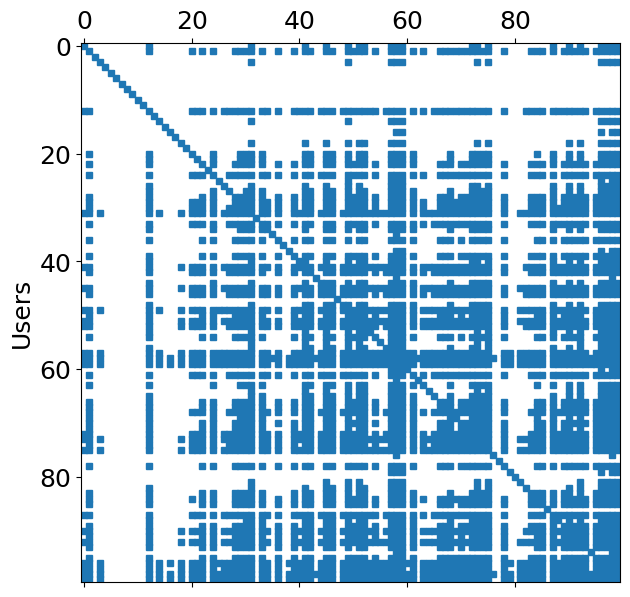

nnz = 3366
nnz/row = 33.66
1100000.0
----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.100000e+06 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=4.38e-04 nnz(S)/p=3.08e+01
* iter=1 time=1.72e-03 obj=1.88e+08 |delta(obj)|/obj=6.44e-02 nnz(X,L,W)/p=[3.08e+01 1.70e+01 5.12e+00] lns_iter=28 
* iter=2 time=2.96e-03 obj=1.71e+08 |delta(obj)|/obj=1.03e-01 nnz(X,L,W)/p=[3.08e+01 1.70e+01 5.95e+01] lns_iter=27 
* iter=3 tim

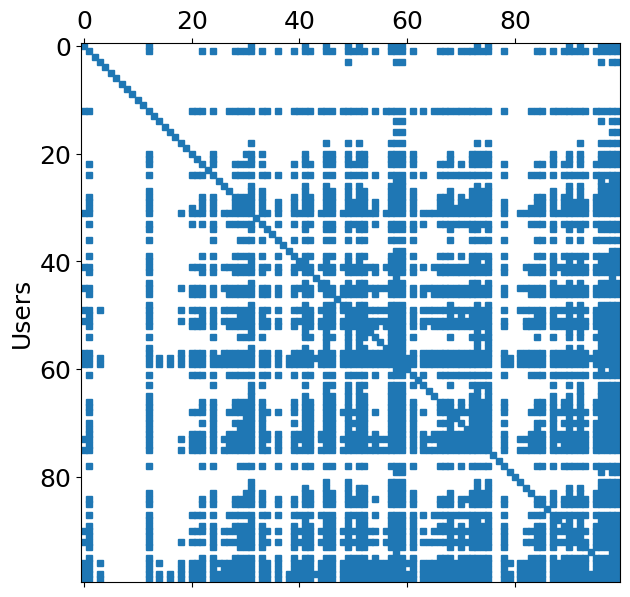

nnz = 3076
nnz/row = 30.76
1200000.0
----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.200000e+06 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=4.35e-04 nnz(S)/p=2.84e+01
* iter=1 time=1.90e-03 obj=2.04e+08 |delta(obj)|/obj=1.37e-01 nnz(X,L,W)/p=[2.84e+01 1.60e+01 4.12e+00] lns_iter=28 
* iter=2 time=3.25e-03 obj=1.92e+08 |delta(obj)|/obj=6.00e-02 nnz(X,L,W)/p=[2.84e+01 1.60e+01 5.19e+01] lns_iter=28 
* iter=3 tim

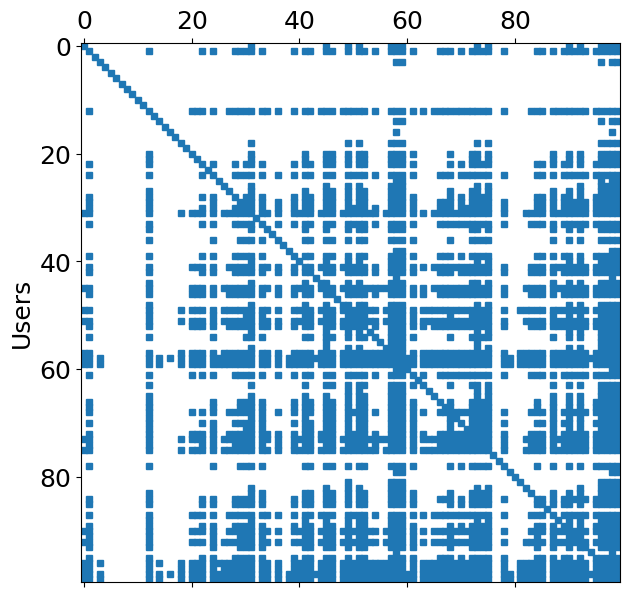

nnz = 2842
nnz/row = 28.42
1300000.0
----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.300000e+06 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=3.73e-04 nnz(S)/p=2.63e+01
* iter=1 time=1.62e-03 obj=2.20e+08 |delta(obj)|/obj=1.98e-01 nnz(X,L,W)/p=[2.63e+01 1.51e+01 3.34e+00] lns_iter=28 
* iter=2 time=2.59e-03 obj=2.05e+08 |delta(obj)|/obj=7.31e-02 nnz(X,L,W)/p=[2.63e+01 1.51e+01 4.85e+01] lns_iter=28 
* iter=3 tim

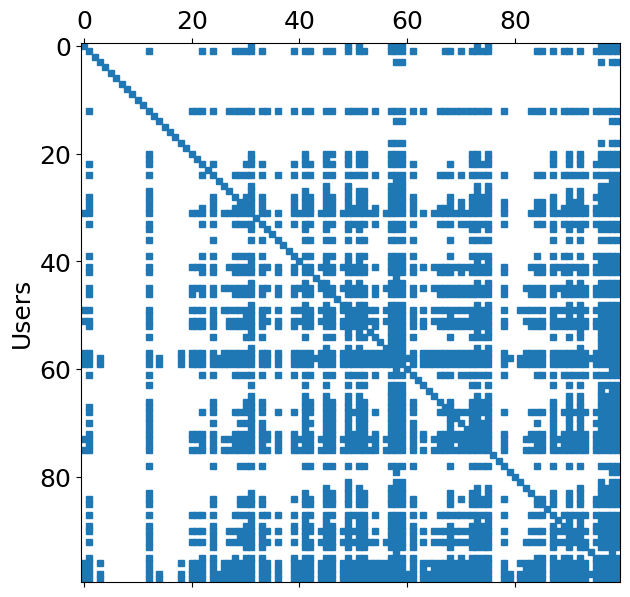

nnz = 2632
nnz/row = 26.32
1400000.0
----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.400000e+06 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=3.40e-04 nnz(S)/p=2.42e+01
* iter=1 time=1.56e-03 obj=2.35e+08 |delta(obj)|/obj=2.50e-01 nnz(X,L,W)/p=[2.42e+01 1.43e+01 2.74e+00] lns_iter=28 
* iter=2 time=2.43e-03 obj=2.17e+08 |delta(obj)|/obj=7.97e-02 nnz(X,L,W)/p=[2.42e+01 1.43e+01 4.48e+01] lns_iter=28 
* iter=3 tim

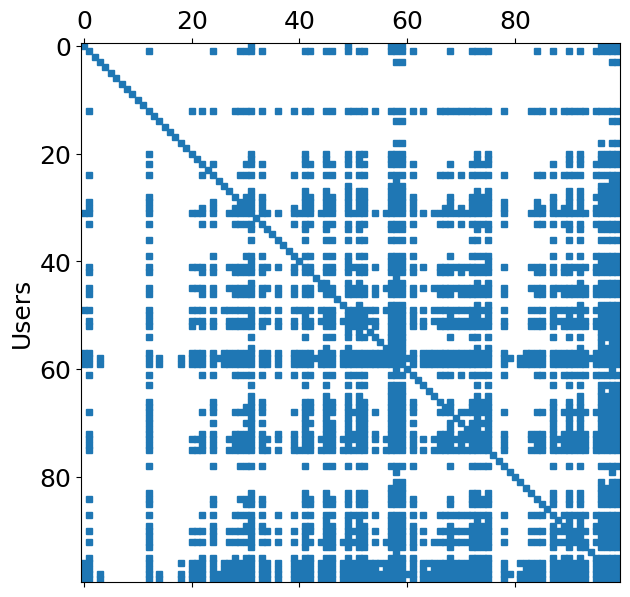

nnz = 2420
nnz/row = 24.2
1500000.0
----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.500000e+06 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=3.29e-04 nnz(S)/p=2.24e+01
* iter=1 time=1.47e-03 obj=2.49e+08 |delta(obj)|/obj=2.94e-01 nnz(X,L,W)/p=[2.24e+01 1.33e+01 2.38e+00] lns_iter=28 
* iter=2 time=2.27e-03 obj=2.29e+08 |delta(obj)|/obj=8.72e-02 nnz(X,L,W)/p=[2.24e+01 1.33e+01 4.31e+01] lns_iter=28 
* iter=3 time

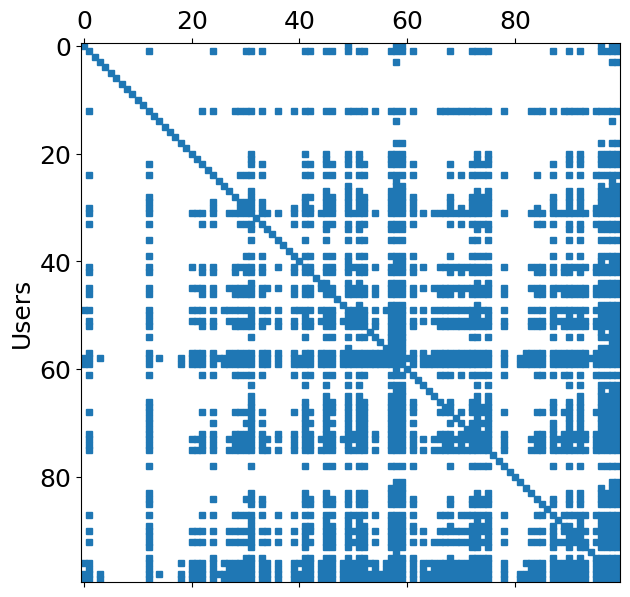

nnz = 2242
nnz/row = 22.42
1600000.0
----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.600000e+06 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=3.59e-04 nnz(S)/p=2.09e+01
* iter=1 time=1.66e-03 obj=2.64e+08 |delta(obj)|/obj=3.33e-01 nnz(X,L,W)/p=[2.09e+01 1.27e+01 2.12e+00] lns_iter=28 
* iter=2 time=2.45e-03 obj=2.42e+08 |delta(obj)|/obj=9.16e-02 nnz(X,L,W)/p=[2.09e+01 1.27e+01 4.13e+01] lns_iter=28 
* iter=3 tim

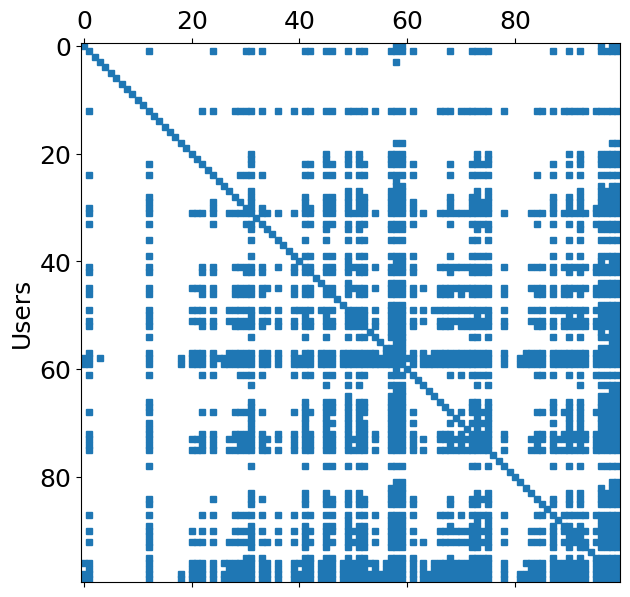

nnz = 2086
nnz/row = 20.86
1700000.0
----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.700000e+06 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=3.36e-04 nnz(S)/p=1.94e+01
* iter=1 time=1.50e-03 obj=2.78e+08 |delta(obj)|/obj=3.67e-01 nnz(X,L,W)/p=[1.94e+01 1.14e+01 1.94e+00] lns_iter=28 
* iter=2 time=2.23e-03 obj=2.54e+08 |delta(obj)|/obj=9.37e-02 nnz(X,L,W)/p=[1.94e+01 1.14e+01 3.87e+01] lns_iter=28 
* iter=3 tim

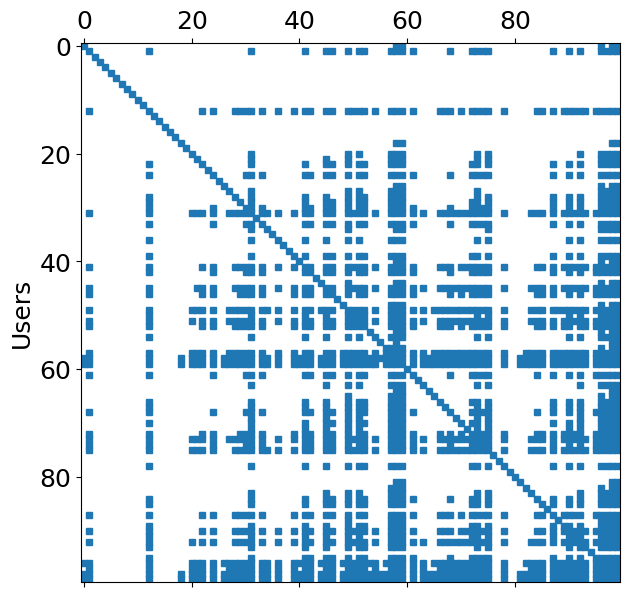

nnz = 1938
nnz/row = 19.38
1800000.0
----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.800000e+06 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=3.12e-04 nnz(S)/p=1.79e+01
* iter=1 time=1.40e-03 obj=2.92e+08 |delta(obj)|/obj=3.97e-01 nnz(X,L,W)/p=[1.79e+01 1.05e+01 1.76e+00] lns_iter=28 
* iter=2 time=2.04e-03 obj=2.67e+08 |delta(obj)|/obj=9.54e-02 nnz(X,L,W)/p=[1.79e+01 1.05e+01 3.58e+01] lns_iter=28 
* iter=3 tim

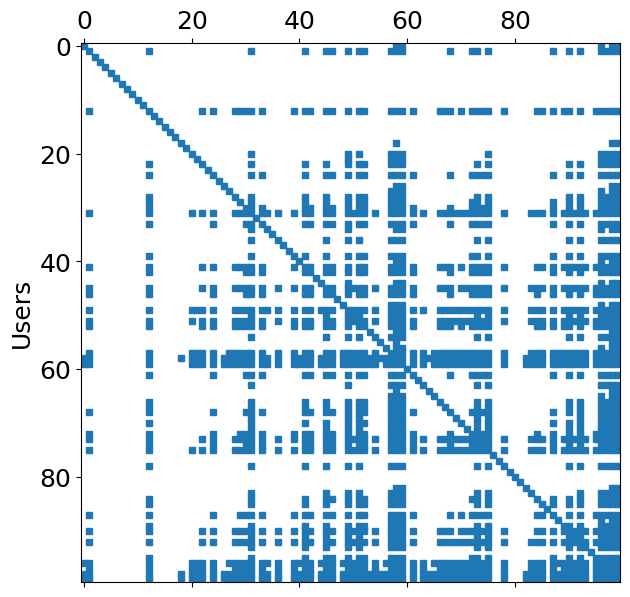

nnz = 1794
nnz/row = 17.94
1900000.0
----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.900000e+06 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=3.21e-04 nnz(S)/p=1.68e+01
* iter=1 time=1.39e-03 obj=3.06e+08 |delta(obj)|/obj=4.24e-01 nnz(X,L,W)/p=[1.68e+01 9.91e+00 1.52e+00] lns_iter=28 
* iter=2 time=1.96e-03 obj=2.78e+08 |delta(obj)|/obj=1.01e-01 nnz(X,L,W)/p=[1.68e+01 9.91e+00 3.52e+01] lns_iter=28 
* iter=3 tim

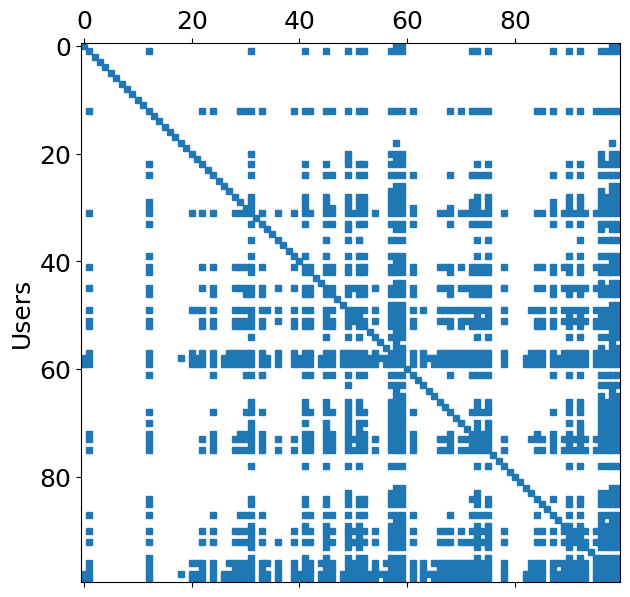

nnz = 1684
nnz/row = 16.84
2000000.0
----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      2.000000e+06 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=3.23e-04 nnz(S)/p=1.58e+01
* iter=1 time=1.31e-03 obj=3.19e+08 |delta(obj)|/obj=4.48e-01 nnz(X,L,W)/p=[1.58e+01 8.86e+00 1.36e+00] lns_iter=28 
* iter=2 time=1.87e-03 obj=2.89e+08 |delta(obj)|/obj=1.05e-01 nnz(X,L,W)/p=[1.58e+01 8.86e+00 3.41e+01] lns_iter=28 
* iter=3 tim

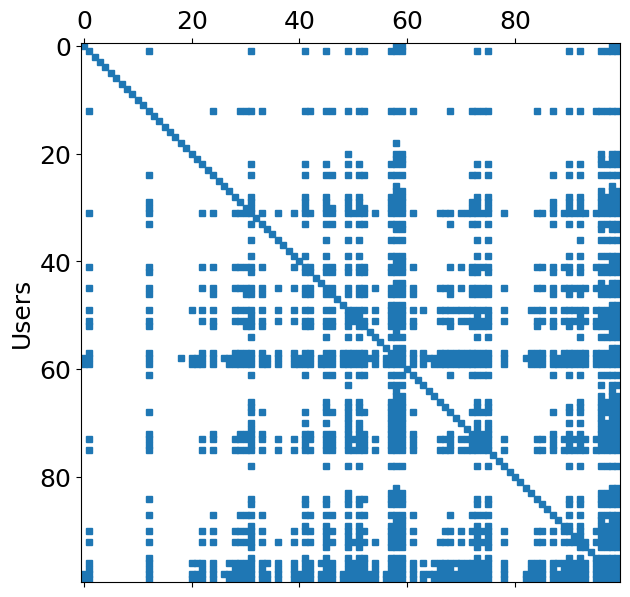

nnz = 1582
nnz/row = 15.82


In [25]:
data_nnz = []
data_nnzr = []
data_time = []

for rho in l:
    print(rho)
    X, computation_time = compute_squic(Y, rho)
    computation_time = round(computation_time, 2)
    rho_dict[rho] = X
    print(f"time required: {computation_time} seconds")

    nonz, nonz_r = count_nnz(rho_dict[rho], ROWS)

    data_nnz.append(nonz)
    data_nnzr.append(nonz_r)
    data_time.append(computation_time)

    if nonz == ROWS:
        print(f"For rho = {rho} just element on the diagonal")
        sparsity_pattern(rho_dict[rho])
    elif nonz == ROWS * ROWS:
        print(f"For rho = {rho} big dense matrix")
        # sparsity_pattern(rho_dict[rho])
        print(f"nnz = {nonz}")
        print(f"nnz/row = {nonz_r}")
    else:
        print(f"For rho = {rho} there are some nnz")
        sparsity_pattern(rho_dict[rho])
        print(f"nnz = {nonz}")
        print(f"nnz/row = {nonz_r}")

data_df = [
    ["NNZ"] + data_nnz,
    ["NNZ/Row"] + data_nnzr,
    ["Time (s)"] + data_time
]

In [26]:
Y = df.T.to_numpy()
# normalize the Y input data to achieve unit variance
Y_new = np.diag(1/np.std(Y,1)) @ Y # each row of Y is scaled by the inverse of its standard deviation
# normalizes each row so that the std dev of each user's balance over the days becomes 1

# Y_new has shape (Users × Days).
# S will have shape (Users × Users).

# double check if this is correct by 
S = np.cov(Y_new, bias=True) # "bias=true" you force cove to use n samples instead of n-1

In [27]:
l = [9e-1, 5e-1, 2e-1, 1e-1, 9e-2, 5e-2, 1e-2, 9e-3, 5e-3, 1e-3, 1e-4]

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.000000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=3.97e-04 nnz(S)/p=3.68e+01
* iter=1 time=1.51e-03 obj=1.72e+02 |delta(obj)|/obj=4.20e-01 nnz(X,L,W)/p=[3.68e+01 2.19e+01 3.13e+01] lns_iter=3 
* iter=2 time=3.51e-03 obj=1.69e+02 |delta(obj)|/obj=2.30e-02 nnz(X,L,W)/p=[3.68e+01 2.19e+01 5.35e+01] lns_iter=1 
* iter=3 time=7.34e-03 obj=1.66e+02 |delta(obj)|/ob

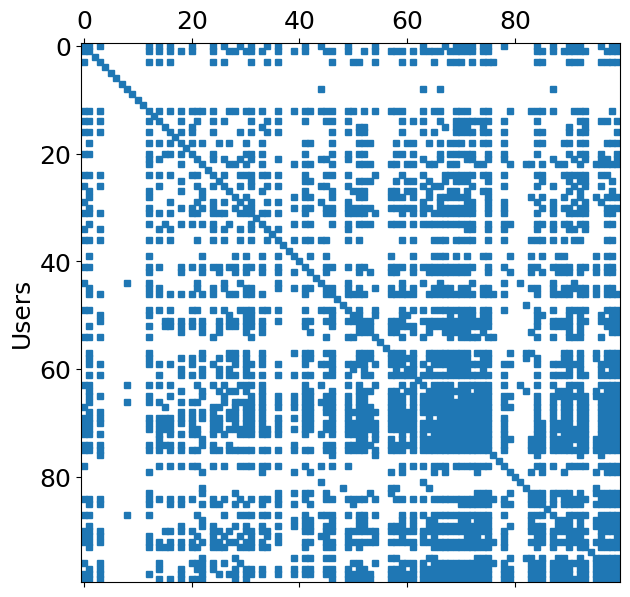

nnz = 2774
nnz/row = 27.74
----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      5.000000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=4.66e-04 nnz(S)/p=7.40e+01
* iter=1 time=1.95e-03 obj=1.26e+02 |delta(obj)|/obj=2.08e-01 nnz(X,L,W)/p=[7.40e+01 4.21e+01 7.58e+01] lns_iter=6 
* iter=2 time=1.07e-02 obj=1.25e+02 |delta(obj)|/obj=9.42e-03 nnz(X,L,W)/p=[7.71e+01 4.09e+01 9.75e+01] lns_iter=1 
* iter=3 time=2.54e-02 o

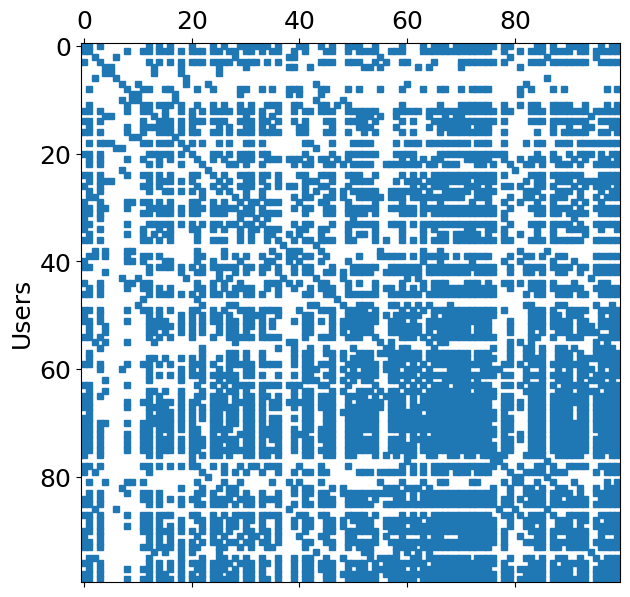

nnz = 4372
nnz/row = 43.72
----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      2.000000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=4.37e-04 nnz(S)/p=8.93e+01
* iter=1 time=2.24e-03 obj=7.01e+01 |delta(obj)|/obj=4.26e-01 nnz(X,L,W)/p=[8.93e+01 4.92e+01 1.00e+00] lns_iter=7 
* iter=2 time=4.29e-03 obj=6.63e+01 |delta(obj)|/obj=5.72e-02 nnz(X,L,W)/p=[8.93e+01 4.92e+01 9.41e+01] lns_iter=10 
* iter=3 time=2.61e-02 

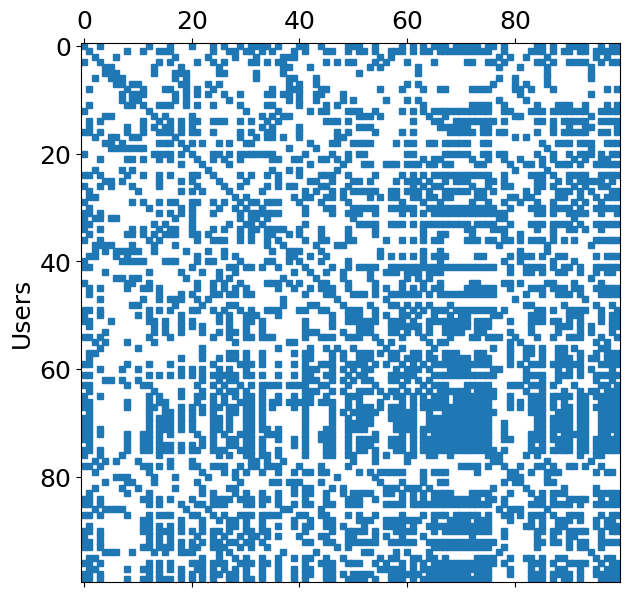

nnz = 3574
nnz/row = 35.74
----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=4.29e-04 nnz(S)/p=9.44e+01
* iter=1 time=2.57e-03 obj=7.61e+01 |delta(obj)|/obj=3.14e-01 nnz(X,L,W)/p=[9.44e+01 5.00e+01 1.00e+00] lns_iter=8 
* iter=2 time=4.50e-03 obj=5.98e+01 |delta(obj)|/obj=2.73e-01 nnz(X,L,W)/p=[9.44e+01 5.00e+01 9.15e+01] lns_iter=9 
* iter=3 time=2.79e-02 o

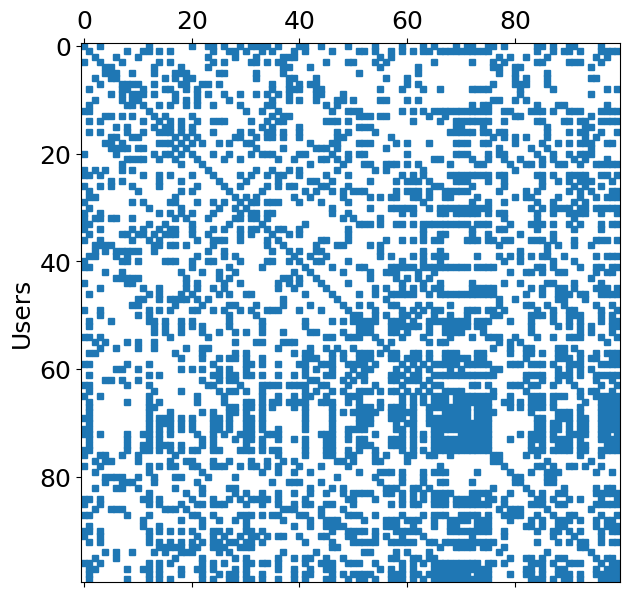

nnz = 3088
nnz/row = 30.88
----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.000000e-02 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=4.09e-04 nnz(S)/p=9.48e+01
* iter=1 time=2.64e-03 obj=7.42e+01 |delta(obj)|/obj=3.48e-01 nnz(X,L,W)/p=[9.48e+01 5.00e+01 1.00e+00] lns_iter=8 
* iter=2 time=4.39e-03 obj=5.74e+01 |delta(obj)|/obj=2.92e-01 nnz(X,L,W)/p=[9.48e+01 5.00e+01 9.17e+01] lns_iter=9 
* iter=3 time=2.88e-02 o

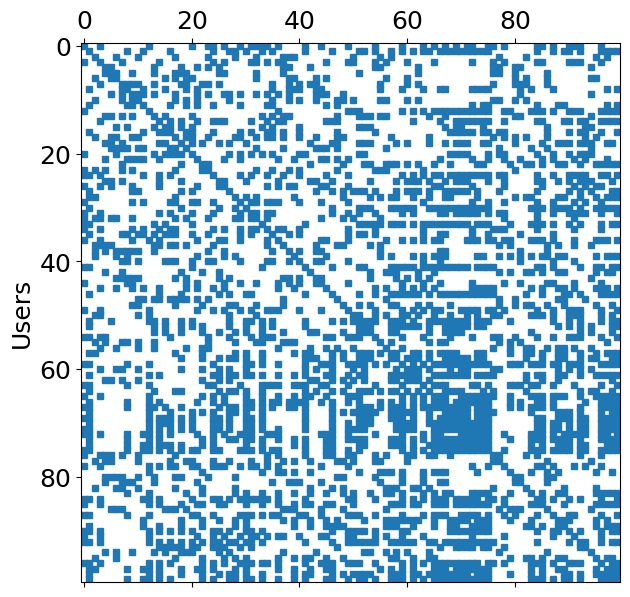

nnz = 3120
nnz/row = 31.2
----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      5.000000e-02 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=4.42e-04 nnz(S)/p=9.68e+01
* iter=1 time=2.46e-03 obj=6.63e+01 |delta(obj)|/obj=5.07e-01 nnz(X,L,W)/p=[9.68e+01 5.00e+01 1.00e+00] lns_iter=8 
* iter=2 time=4.44e-03 obj=4.78e+01 |delta(obj)|/obj=3.87e-01 nnz(X,L,W)/p=[9.68e+01 5.00e+01 9.20e+01] lns_iter=9 
* iter=3 time=2.87e-02 ob

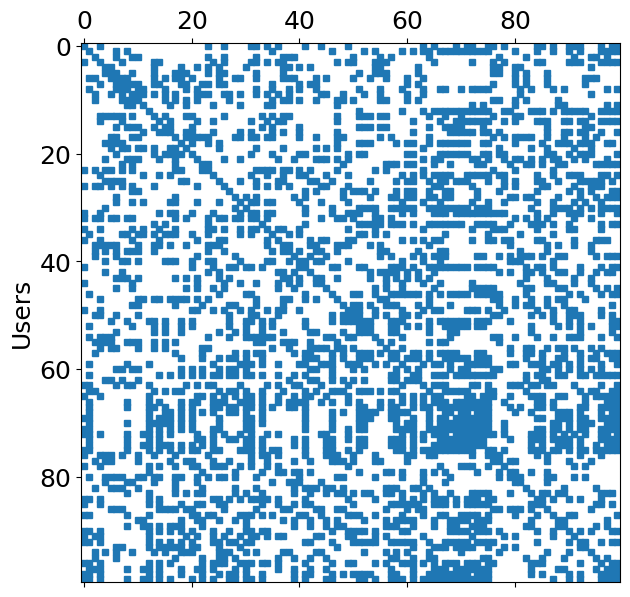

nnz = 3140
nnz/row = 31.4
----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e-02 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=3.91e-04 nnz(S)/p=9.94e+01
* iter=1 time=2.62e-03 obj=5.83e+01 |delta(obj)|/obj=7.16e-01 nnz(X,L,W)/p=[9.94e+01 5.00e+01 1.00e+00] lns_iter=8 
* iter=2 time=4.50e-03 obj=3.79e+01 |delta(obj)|/obj=5.36e-01 nnz(X,L,W)/p=[9.94e+01 5.00e+01 9.30e+01] lns_iter=9 
* iter=3 time=3.04e-02 ob

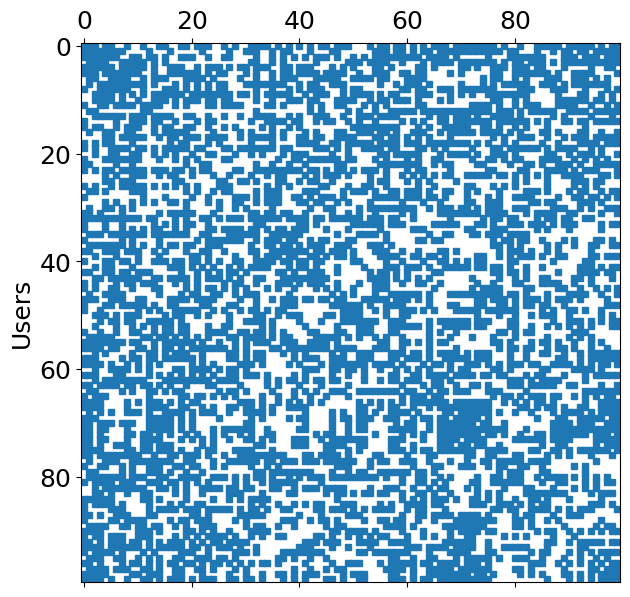

nnz = 4744
nnz/row = 47.44
----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.000000e-03 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=4.13e-04 nnz(S)/p=9.95e+01
* iter=1 time=2.63e-03 obj=5.81e+01 |delta(obj)|/obj=7.22e-01 nnz(X,L,W)/p=[9.95e+01 5.00e+01 1.00e+00] lns_iter=8 
* iter=2 time=4.87e-03 obj=3.77e+01 |delta(obj)|/obj=5.40e-01 nnz(X,L,W)/p=[9.95e+01 5.00e+01 9.30e+01] lns_iter=9 
* iter=3 time=2.98e-02 o

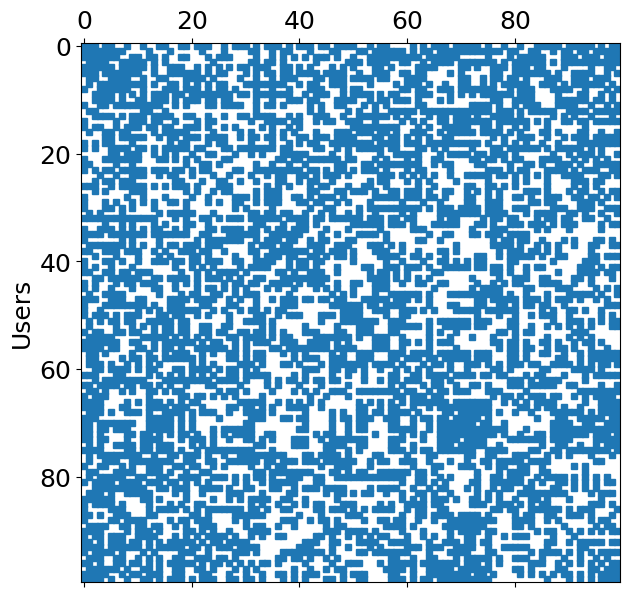

nnz = 4938
nnz/row = 49.38
----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      5.000000e-03 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=5.05e-04 nnz(S)/p=9.97e+01
* iter=1 time=2.71e-03 obj=5.72e+01 |delta(obj)|/obj=7.47e-01 nnz(X,L,W)/p=[9.97e+01 5.00e+01 1.00e+00] lns_iter=8 
* iter=2 time=4.69e-03 obj=3.67e+01 |delta(obj)|/obj=5.60e-01 nnz(X,L,W)/p=[9.97e+01 5.00e+01 9.30e+01] lns_iter=9 
* iter=3 time=3.01e-02 o

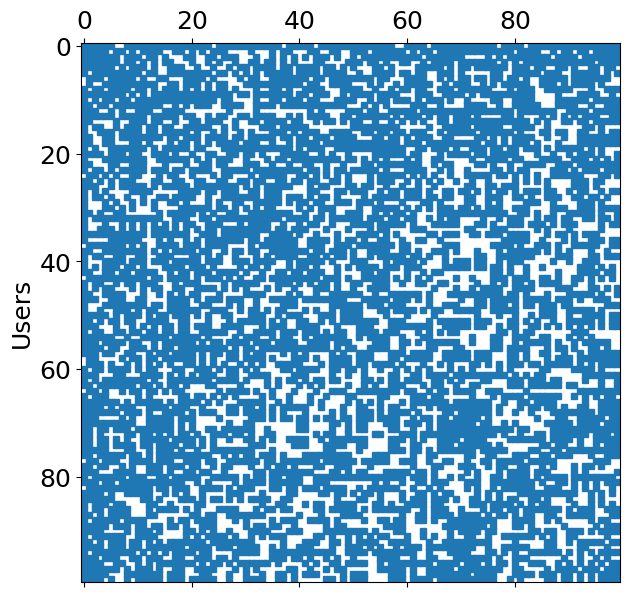

nnz = 5822
nnz/row = 58.22
----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e-03 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=4.82e-04 nnz(S)/p=1.00e+02
* iter=1 time=2.72e-03 obj=5.64e+01 |delta(obj)|/obj=7.72e-01 nnz(X,L,W)/p=[1.00e+02 5.00e+01 1.00e+00] lns_iter=8 
* iter=2 time=4.68e-03 obj=3.57e+01 |delta(obj)|/obj=5.81e-01 nnz(X,L,W)/p=[1.00e+02 5.00e+01 9.31e+01] lns_iter=9 
* iter=3 time=4.18e-02 o

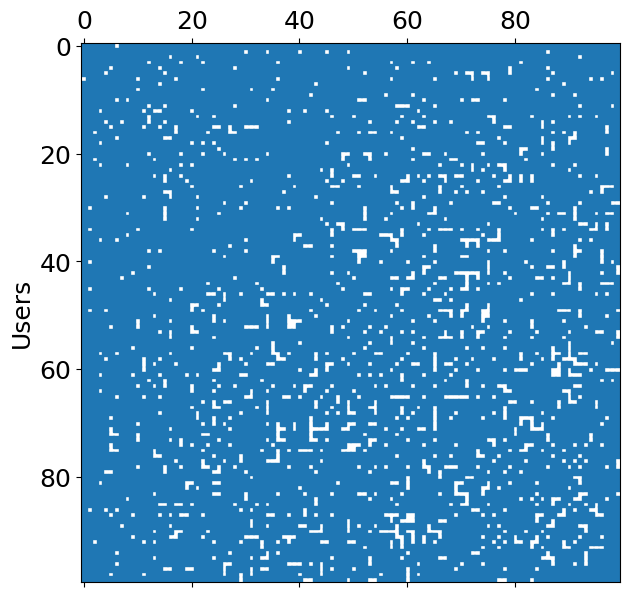

nnz = 8614
nnz/row = 86.14
----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e-04 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=6.32e-04 nnz(S)/p=1.00e+02
* iter=1 time=2.78e-03 obj=5.62e+01 |delta(obj)|/obj=7.78e-01 nnz(X,L,W)/p=[1.00e+02 5.00e+01 1.00e+00] lns_iter=8 
* iter=2 time=5.04e-03 obj=3.55e+01 |delta(obj)|/obj=5.86e-01 nnz(X,L,W)/p=[1.00e+02 5.00e+01 9.31e+01] lns_iter=9 
* iter=3 time=3.18e-02 o

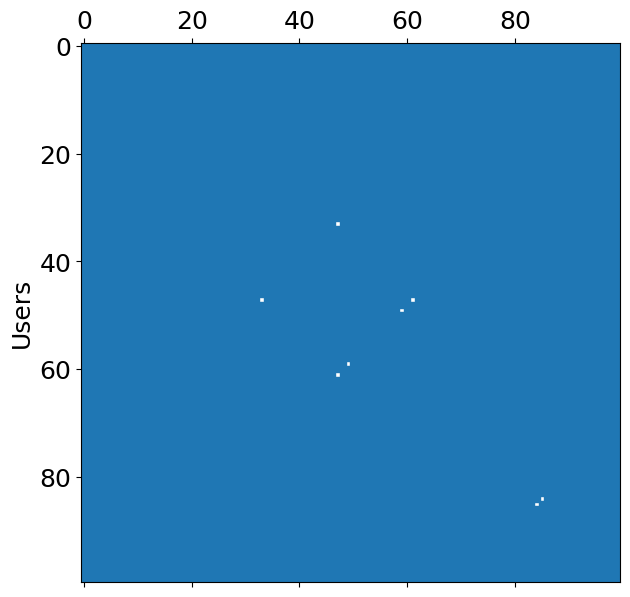

nnz = 9992
nnz/row = 99.92


In [28]:
data_nnz = []
data_nnzr = []
data_time = []

for rho in l:
    X, computation_time = compute_squic(Y_new, rho)
    computation_time = round(computation_time, 2)
    rho_dict[rho] = X
    print(f"time required: {computation_time} seconds")

    nonz, nonz_r = count_nnz(rho_dict[rho], ROWS)

    data_nnz.append(nonz)
    data_nnzr.append(nonz_r)
    data_time.append(computation_time)

    if nonz == ROWS:
        print(f"For rho = {rho} just element on the diagonal")
        sparsity_pattern(rho_dict[rho])
    elif nonz == ROWS * ROWS:
        print(f"For rho = {rho} big dense matrix")
        sparsity_pattern(rho_dict[rho])
        print(f"nnz = {nonz}")
        print(f"nnz/row = {nonz_r}")
    else:
        print(f"For rho = {rho} there are some nnz")
        sparsity_pattern(rho_dict[rho])
        print(f"nnz = {nonz}")
        print(f"nnz/row = {nonz_r}")

data_df = [
    ["NNZ"] + data_nnz,
    ["NNZ/Row"] + data_nnzr,
    ["Time (s)"] + data_time
]

## Squic-FIT

In [29]:
fit_dict = {}

In [30]:
Y = df.T.to_numpy()  # Convert to (users, days)

In [31]:
l = [1e5, 2e5, 3e5, 4e5, 5e5, 6e5, 7e5, 8e5, 9e5, 10e5, 11e5, 12e5, 13e5, 14e5, 15e5, 16e5, 17e5, 18e5, 19e5, 20e5]

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e+05 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=1.04e-03 nnz(S)/p=7.83e+01
* iter=1 time=3.86e-03 obj=9.12e+07 |delta(obj)|/obj=9.29e-01 nnz(X,L,W)/p=[7.83e+01 4.18e+01 1.02e+00] lns_iter=29 
* iter=2 time=5.70e-03 obj=4.89e+07 |delta(obj)|/obj=8.67e-01 nnz(X,L,W)/p=[7.83e+01 4.18e+01 6.11e+01] lns_iter=30 
* iter=3 time=1.91e-02 obj=3.32e+07 |delta(obj)|/

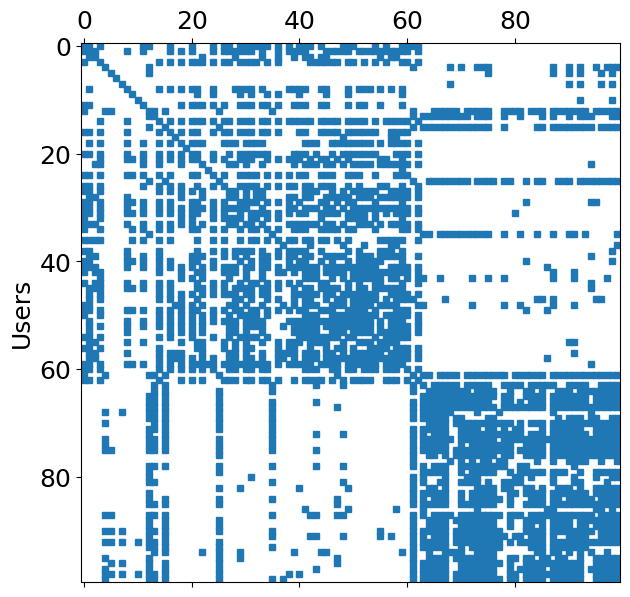

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      2.000000e+05 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=3.89e-04 nnz(S)/p=6.89e+01
* iter=1 time=2.68e-03 obj=1.08e+08 |delta(obj)|/obj=6.36e-01 nnz(X,L,W)/p=[6.89e+01 3.78e+01 1.00e+00] lns_iter=29 
* iter=2 time=4.47e-03 obj=6.73e+07 |delta(obj)|/obj=5.98e-01 nnz(X,L,W)/p=[6.89e+01 3.78e+01 5.96e+01] lns_iter=30 
* iter=3 time=1.70e-02 obj=4.87e+07 |delta(obj)|/

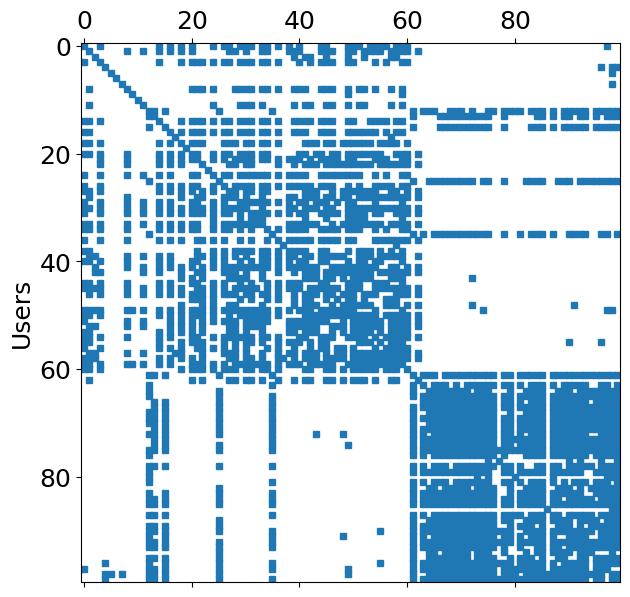

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      3.000000e+05 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=5.69e-04 nnz(S)/p=6.24e+01
* iter=1 time=2.54e-03 obj=1.23e+08 |delta(obj)|/obj=4.25e-01 nnz(X,L,W)/p=[6.24e+01 3.43e+01 1.00e+00] lns_iter=29 
* iter=2 time=3.88e-03 obj=8.58e+07 |delta(obj)|/obj=4.40e-01 nnz(X,L,W)/p=[6.24e+01 3.43e+01 5.73e+01] lns_iter=30 
* iter=3 time=1.90e-02 obj=5.87e+07 |delta(obj)|/

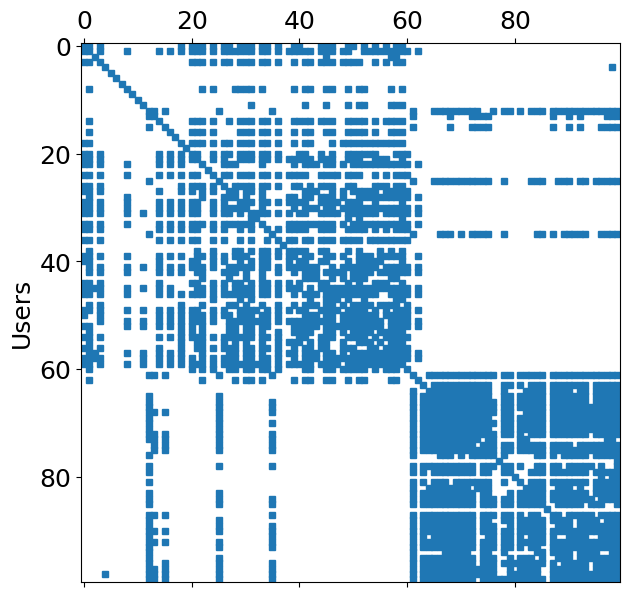

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      4.000000e+05 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=4.22e-04 nnz(S)/p=5.66e+01
* iter=1 time=2.64e-03 obj=1.39e+08 |delta(obj)|/obj=2.67e-01 nnz(X,L,W)/p=[5.66e+01 3.11e+01 1.00e+00] lns_iter=29 
* iter=2 time=3.60e-03 obj=1.04e+08 |delta(obj)|/obj=3.41e-01 nnz(X,L,W)/p=[5.66e+01 3.11e+01 5.50e+01] lns_iter=30 
* iter=3 time=1.32e-02 obj=7.43e+07 |delta(obj)|/

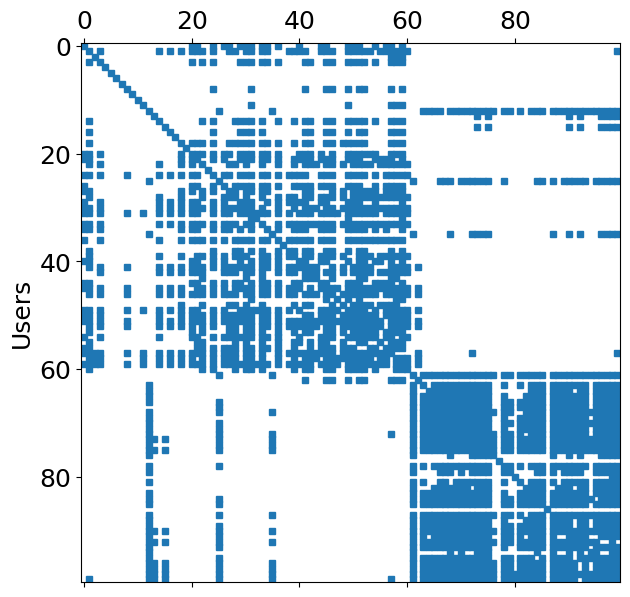

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      5.000000e+05 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=4.53e-04 nnz(S)/p=5.18e+01
* iter=1 time=2.68e-03 obj=1.54e+08 |delta(obj)|/obj=1.44e-01 nnz(X,L,W)/p=[5.18e+01 2.85e+01 1.00e+00] lns_iter=29 
* iter=2 time=3.59e-03 obj=8.76e+07 |delta(obj)|/obj=7.56e-01 nnz(X,L,W)/p=[5.18e+01 2.85e+01 7.03e+01] lns_iter=29 
* iter=3 time=1.39e-02 obj=8.57e+07 |delta(obj)|/

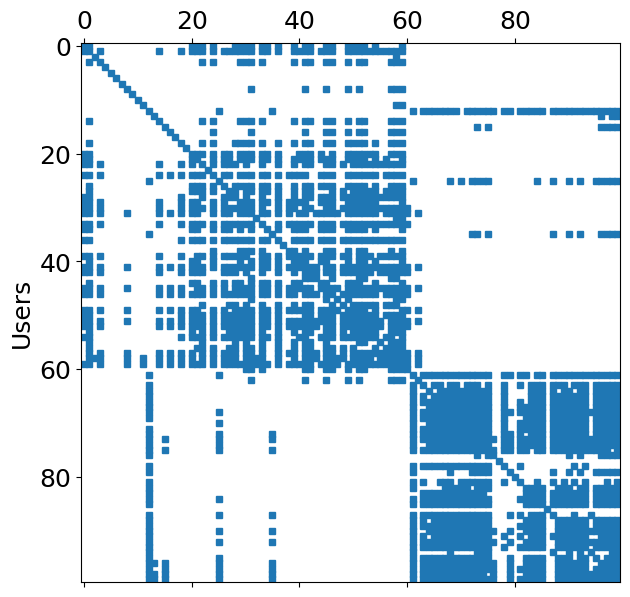

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      6.000000e+05 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=5.35e-04 nnz(S)/p=4.75e+01
* iter=1 time=2.25e-03 obj=1.01e+08 |delta(obj)|/obj=7.42e-01 nnz(X,L,W)/p=[4.75e+01 2.63e+01 4.76e+01] lns_iter=28 
* iter=2 time=6.57e-03 obj=1.00e+08 |delta(obj)|/obj=7.80e-03 nnz(X,L,W)/p=[4.75e+01 2.63e+01 6.90e+01] lns_iter=22 
* iter=3 time=1.27e-02 obj=1.00e+08 |delta(obj)|/

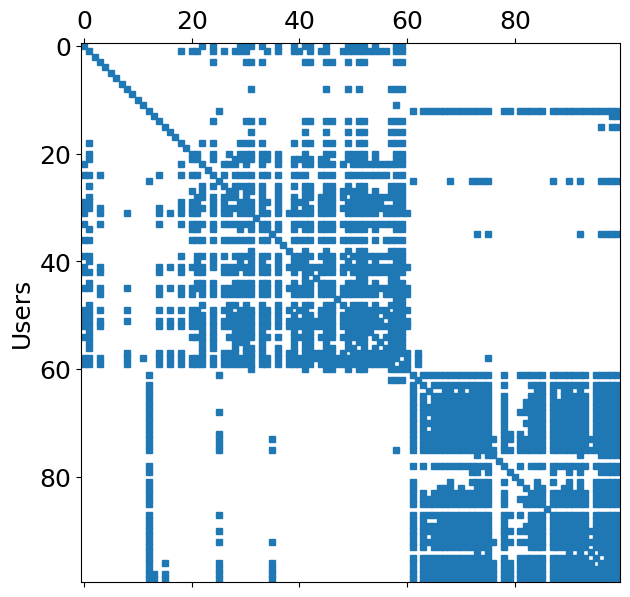

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      7.000000e+05 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=4.09e-04 nnz(S)/p=4.33e+01
* iter=1 time=1.98e-03 obj=1.20e+08 |delta(obj)|/obj=4.71e-01 nnz(X,L,W)/p=[4.33e+01 2.40e+01 2.67e+01] lns_iter=28 
* iter=2 time=4.84e-03 obj=1.18e+08 |delta(obj)|/obj=1.15e-02 nnz(X,L,W)/p=[4.33e+01 2.40e+01 5.70e+01] lns_iter=28 
* iter=3 time=1.04e-02 obj=1.17e+08 |delta(obj)|/

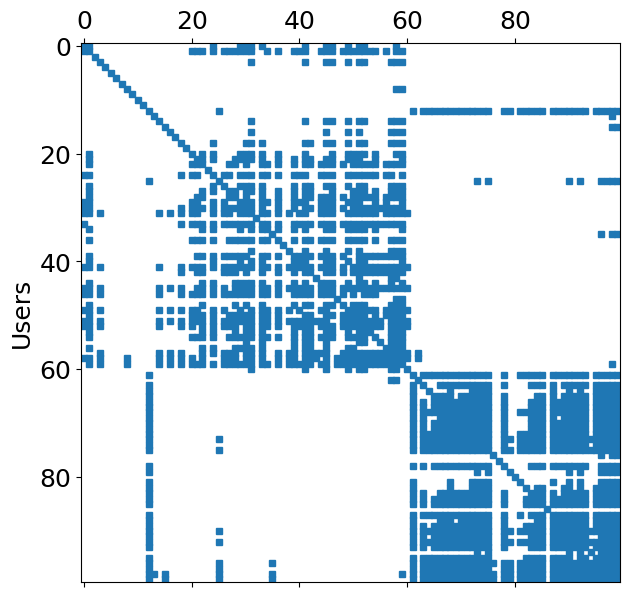

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      8.000000e+05 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=4.11e-04 nnz(S)/p=3.99e+01
* iter=1 time=2.06e-03 obj=1.38e+08 |delta(obj)|/obj=2.79e-01 nnz(X,L,W)/p=[3.99e+01 2.19e+01 1.58e+01] lns_iter=28 
* iter=2 time=3.96e-03 obj=1.35e+08 |delta(obj)|/obj=2.11e-02 nnz(X,L,W)/p=[3.99e+01 2.19e+01 5.91e+01] lns_iter=28 
* iter=3 time=9.92e-03 obj=1.31e+08 |delta(obj)|/

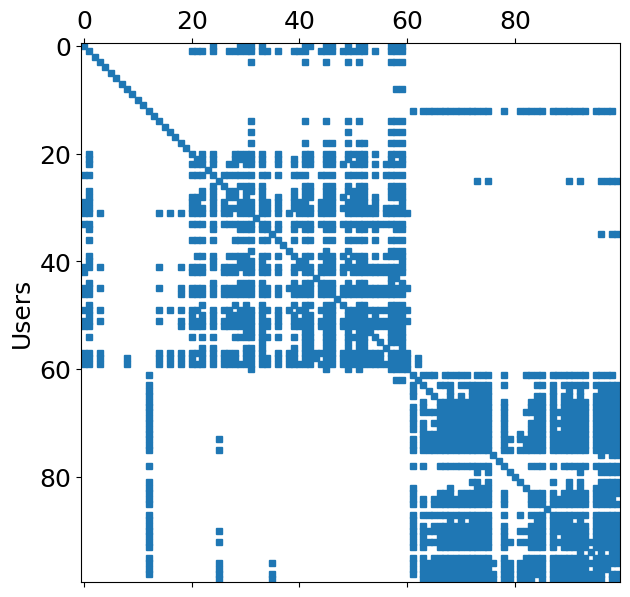

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.000000e+05 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=5.07e-04 nnz(S)/p=3.65e+01
* iter=1 time=1.84e-03 obj=1.55e+08 |delta(obj)|/obj=1.36e-01 nnz(X,L,W)/p=[3.65e+01 2.02e+01 1.01e+01] lns_iter=28 
* iter=2 time=3.53e-03 obj=1.45e+08 |delta(obj)|/obj=6.60e-02 nnz(X,L,W)/p=[3.65e+01 2.02e+01 6.25e+01] lns_iter=27 
* iter=3 time=9.36e-03 obj=1.43e+08 |delta(obj)|/

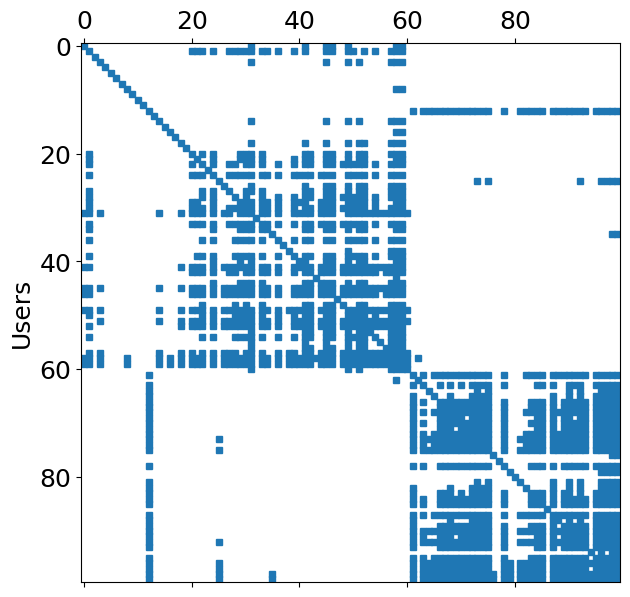

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e+06 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=3.63e-04 nnz(S)/p=3.37e+01
* iter=1 time=1.88e-03 obj=1.72e+08 |delta(obj)|/obj=2.47e-02 nnz(X,L,W)/p=[3.37e+01 1.85e+01 7.04e+00] lns_iter=28 
* iter=2 time=3.42e-03 obj=1.58e+08 |delta(obj)|/obj=8.77e-02 nnz(X,L,W)/p=[3.37e+01 1.85e+01 6.26e+01] lns_iter=27 
* iter=3 time=9.66e-03 obj=1.57e+08 |delta(obj)|/

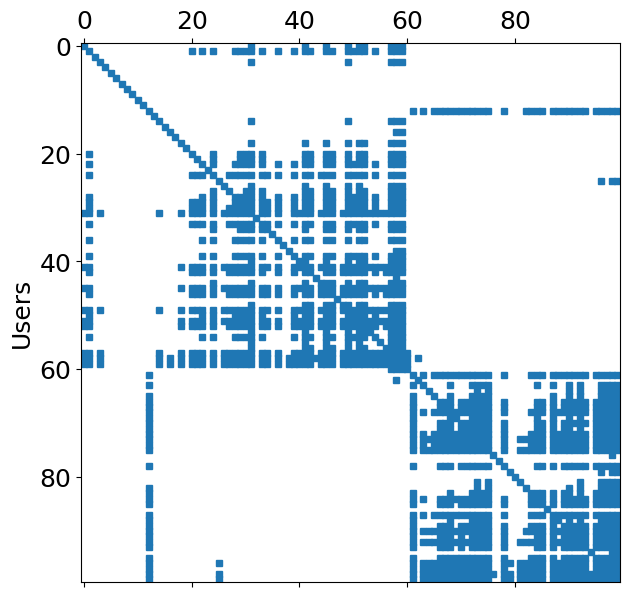

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.100000e+06 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=4.12e-04 nnz(S)/p=3.08e+01
* iter=1 time=1.80e-03 obj=1.88e+08 |delta(obj)|/obj=6.44e-02 nnz(X,L,W)/p=[3.08e+01 1.70e+01 5.12e+00] lns_iter=28 
* iter=2 time=2.86e-03 obj=1.71e+08 |delta(obj)|/obj=1.03e-01 nnz(X,L,W)/p=[3.08e+01 1.70e+01 5.95e+01] lns_iter=27 
* iter=3 time=8.25e-03 obj=1.70e+08 |delta(obj)|/

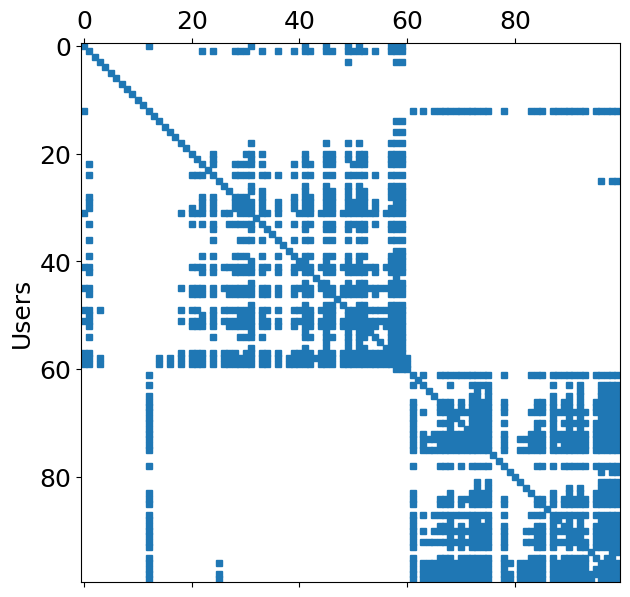

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.200000e+06 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=3.73e-04 nnz(S)/p=2.84e+01
* iter=1 time=1.75e-03 obj=2.04e+08 |delta(obj)|/obj=1.37e-01 nnz(X,L,W)/p=[2.84e+01 1.60e+01 4.12e+00] lns_iter=28 
* iter=2 time=2.63e-03 obj=1.92e+08 |delta(obj)|/obj=6.00e-02 nnz(X,L,W)/p=[2.84e+01 1.60e+01 5.19e+01] lns_iter=28 
* iter=3 time=7.44e-03 obj=1.86e+08 |delta(obj)|/

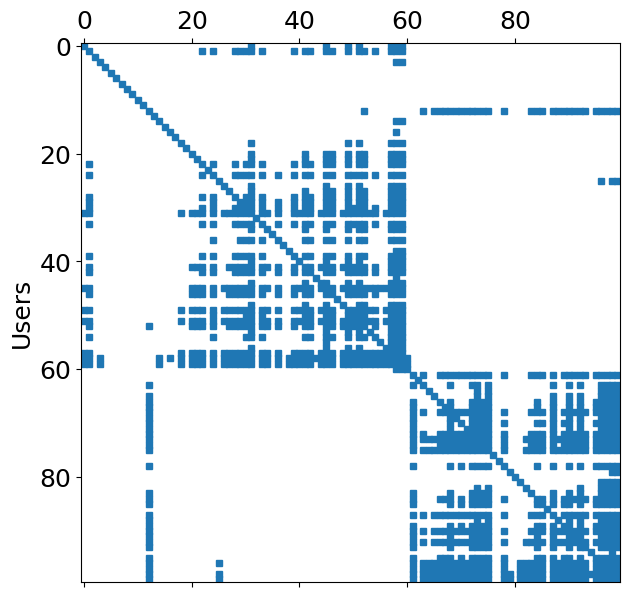

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.300000e+06 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=3.71e-04 nnz(S)/p=2.63e+01
* iter=1 time=1.75e-03 obj=2.20e+08 |delta(obj)|/obj=1.98e-01 nnz(X,L,W)/p=[2.63e+01 1.51e+01 3.34e+00] lns_iter=28 
* iter=2 time=2.77e-03 obj=2.05e+08 |delta(obj)|/obj=7.31e-02 nnz(X,L,W)/p=[2.63e+01 1.51e+01 4.85e+01] lns_iter=28 
* iter=3 time=6.92e-03 obj=2.00e+08 |delta(obj)|/

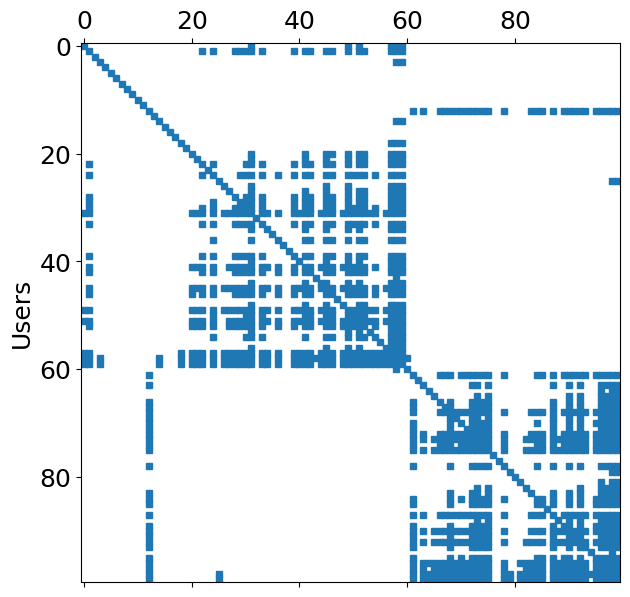

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.400000e+06 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=3.61e-04 nnz(S)/p=2.42e+01
* iter=1 time=1.67e-03 obj=2.35e+08 |delta(obj)|/obj=2.50e-01 nnz(X,L,W)/p=[2.42e+01 1.43e+01 2.74e+00] lns_iter=28 
* iter=2 time=2.52e-03 obj=2.17e+08 |delta(obj)|/obj=7.97e-02 nnz(X,L,W)/p=[2.42e+01 1.43e+01 4.48e+01] lns_iter=28 
* iter=3 time=6.06e-03 obj=2.13e+08 |delta(obj)|/

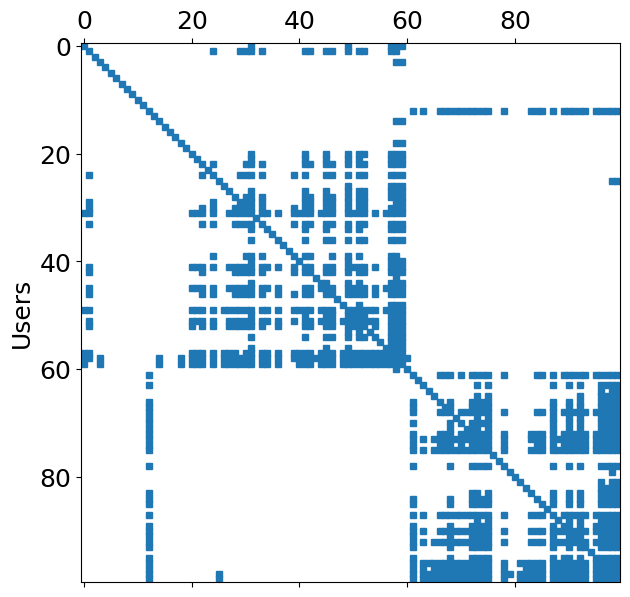

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.500000e+06 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=3.34e-04 nnz(S)/p=2.24e+01
* iter=1 time=1.50e-03 obj=2.49e+08 |delta(obj)|/obj=2.94e-01 nnz(X,L,W)/p=[2.24e+01 1.33e+01 2.38e+00] lns_iter=28 
* iter=2 time=2.56e-03 obj=2.29e+08 |delta(obj)|/obj=8.72e-02 nnz(X,L,W)/p=[2.24e+01 1.33e+01 4.31e+01] lns_iter=28 
* iter=3 time=5.66e-03 obj=2.23e+08 |delta(obj)|/

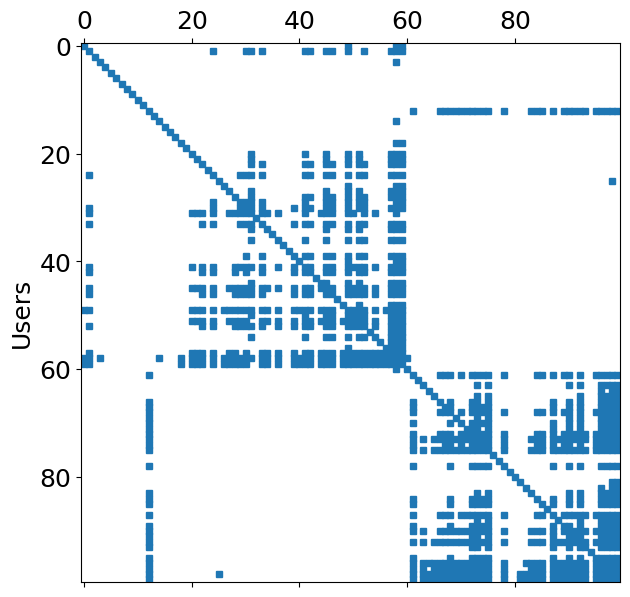

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.600000e+06 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=4.74e-04 nnz(S)/p=2.09e+01
* iter=1 time=1.55e-03 obj=2.64e+08 |delta(obj)|/obj=3.33e-01 nnz(X,L,W)/p=[2.09e+01 1.27e+01 2.12e+00] lns_iter=28 
* iter=2 time=2.31e-03 obj=2.42e+08 |delta(obj)|/obj=9.16e-02 nnz(X,L,W)/p=[2.09e+01 1.27e+01 4.13e+01] lns_iter=28 
* iter=3 time=5.34e-03 obj=2.36e+08 |delta(obj)|/

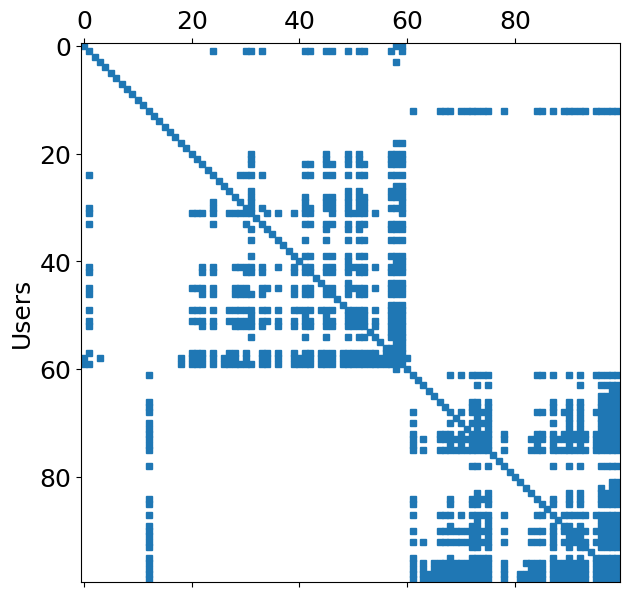

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.700000e+06 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=4.63e-04 nnz(S)/p=1.94e+01
* iter=1 time=1.37e-03 obj=2.78e+08 |delta(obj)|/obj=3.67e-01 nnz(X,L,W)/p=[1.94e+01 1.14e+01 1.94e+00] lns_iter=28 
* iter=2 time=2.19e-03 obj=2.54e+08 |delta(obj)|/obj=9.37e-02 nnz(X,L,W)/p=[1.94e+01 1.14e+01 3.87e+01] lns_iter=28 
* iter=3 time=5.08e-03 obj=2.49e+08 |delta(obj)|/

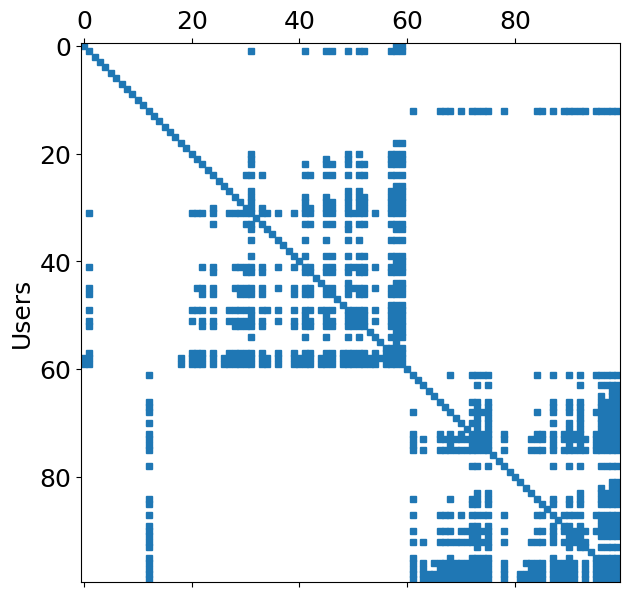

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.800000e+06 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=3.71e-04 nnz(S)/p=1.79e+01
* iter=1 time=1.35e-03 obj=2.92e+08 |delta(obj)|/obj=3.97e-01 nnz(X,L,W)/p=[1.79e+01 1.05e+01 1.76e+00] lns_iter=28 
* iter=2 time=2.06e-03 obj=2.67e+08 |delta(obj)|/obj=9.54e-02 nnz(X,L,W)/p=[1.79e+01 1.05e+01 3.58e+01] lns_iter=28 
* iter=3 time=4.72e-03 obj=2.61e+08 |delta(obj)|/

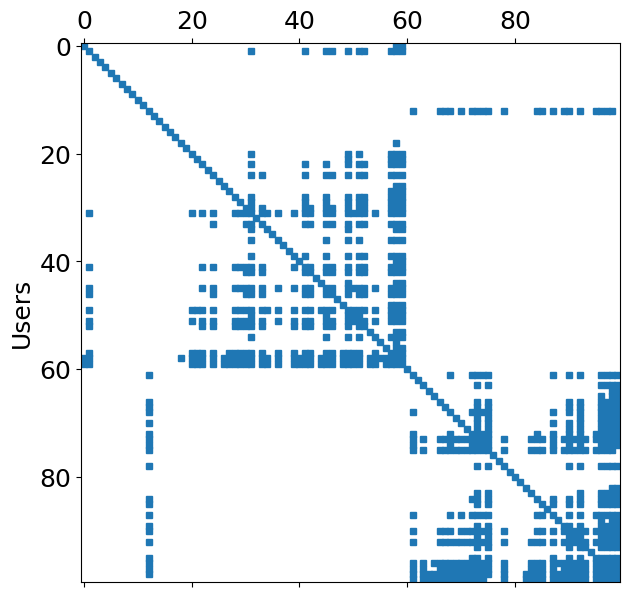

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.900000e+06 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=3.77e-04 nnz(S)/p=1.68e+01
* iter=1 time=1.43e-03 obj=3.06e+08 |delta(obj)|/obj=4.24e-01 nnz(X,L,W)/p=[1.68e+01 9.91e+00 1.52e+00] lns_iter=28 
* iter=2 time=2.07e-03 obj=2.78e+08 |delta(obj)|/obj=1.01e-01 nnz(X,L,W)/p=[1.68e+01 9.91e+00 3.52e+01] lns_iter=28 
* iter=3 time=4.94e-03 obj=2.74e+08 |delta(obj)|/

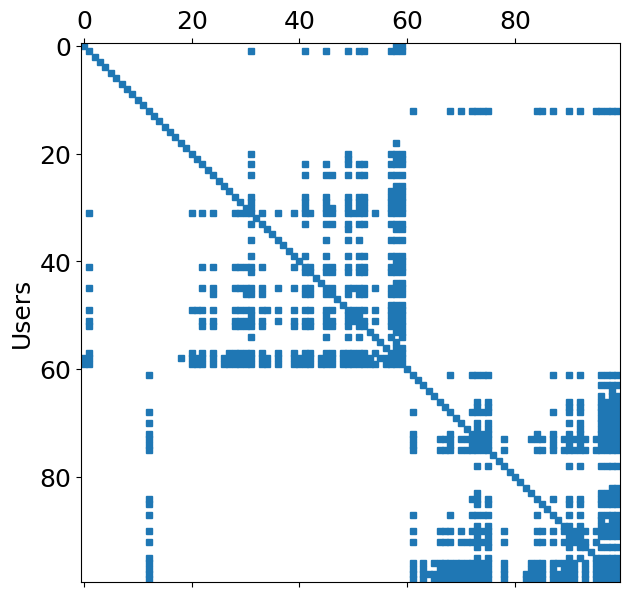

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      2.000000e+06 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=4.57e-04 nnz(S)/p=1.58e+01
* iter=1 time=1.42e-03 obj=3.19e+08 |delta(obj)|/obj=4.48e-01 nnz(X,L,W)/p=[1.58e+01 8.86e+00 1.36e+00] lns_iter=28 
* iter=2 time=6.27e-03 obj=2.89e+08 |delta(obj)|/obj=1.05e-01 nnz(X,L,W)/p=[1.58e+01 8.86e+00 3.41e+01] lns_iter=28 
* iter=3 time=4.48e-03 obj=2.85e+08 |delta(obj)|/

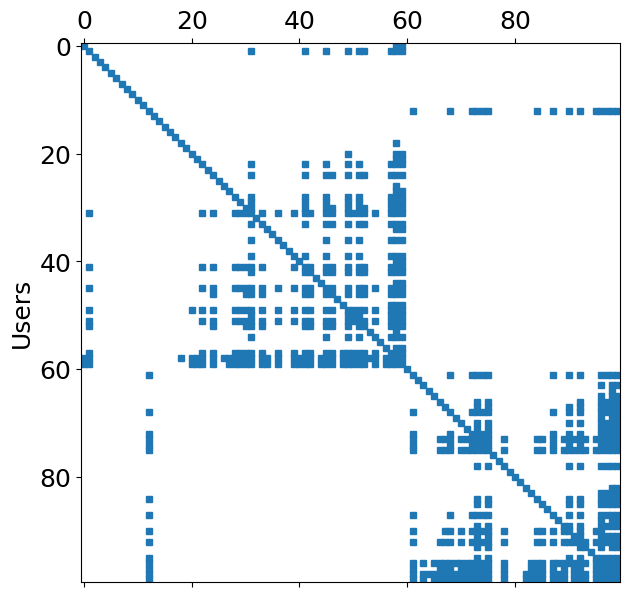

In [33]:
data_nnz = []
data_nnzr = []
data_time = []

for rho in l:
    fit_dict[rho], end_time = squic_fit(Y, lambda_val=rho, eta=rho * 0.1)
    end_time = round(end_time, 2)
    print(f"required time: {end_time}")

    nnz, nnz_r = nnz_fit(fit_dict[rho], ROWS)
    print(f"nnz = {nnz} per rows = {nnz_r}")

    sparsity_pattern(fit_dict[rho])

    data_nnz.append(nnz)
    data_nnzr.append(nnz_r)
    data_time.append(end_time)

data_fit = [
    ["NNZ"] + data_nnz,
    ["NNZ/Row"] + data_nnzr,
    ["Time (s)"] + data_time
]

In [30]:
# normalize the Y input data to achieve unit variance
Y_new = np.diag(1/np.std(Y,1)) @ Y # each row of Y is scaled by the inverse of its standard deviation
# normalizes each row so that the std dev of each user's balance over the days becomes 1

# Y_new has shape (Users × Days).
# S will have shape (Users × Users).

# double check if this is correct by 
S = np.cov(Y_new, bias=True) # "bias=true" you force cove to use n samples instead of n-1

In [31]:
S

array([[ 1.        ,  0.94028376,  0.48883488, ..., -0.92083345,
        -0.93259953, -0.94831661],
       [ 0.94028376,  1.        ,  0.60968693, ..., -0.97884399,
        -0.97557493, -0.99138276],
       [ 0.48883488,  0.60968693,  1.        , ..., -0.67177945,
        -0.60060746, -0.6049956 ],
       ...,
       [-0.92083345, -0.97884399, -0.67177945, ...,  1.        ,
         0.98008111,  0.98818264],
       [-0.93259953, -0.97557493, -0.60060746, ...,  0.98008111,
         1.        ,  0.9881591 ],
       [-0.94831661, -0.99138276, -0.6049956 , ...,  0.98818264,
         0.9881591 ,  1.        ]])

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.000000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=4.11e-04 nnz(S)/p=3.68e+01
* iter=1 time=1.62e-03 obj=1.72e+02 |delta(obj)|/obj=4.20e-01 nnz(X,L,W)/p=[3.68e+01 2.19e+01 3.13e+01] lns_iter=3 
* iter=2 time=3.47e-03 obj=1.69e+02 |delta(obj)|/obj=2.30e-02 nnz(X,L,W)/p=[3.68e+01 2.19e+01 5.35e+01] lns_iter=1 
* iter=3 time=7.30e-03 obj=1.66e+02 |delta(obj)|/ob

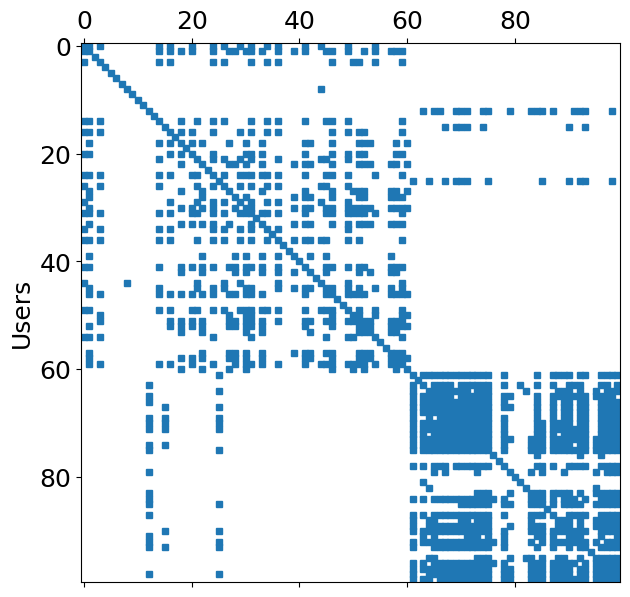

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      5.000000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=4.14e-04 nnz(S)/p=7.40e+01
* iter=1 time=2.03e-03 obj=1.26e+02 |delta(obj)|/obj=2.08e-01 nnz(X,L,W)/p=[7.40e+01 4.21e+01 7.58e+01] lns_iter=6 
* iter=2 time=1.07e-02 obj=1.25e+02 |delta(obj)|/obj=9.42e-03 nnz(X,L,W)/p=[7.71e+01 4.09e+01 9.75e+01] lns_iter=1 
* iter=3 time=2.56e-02 obj=1.24e+02 |delta(obj)|/ob

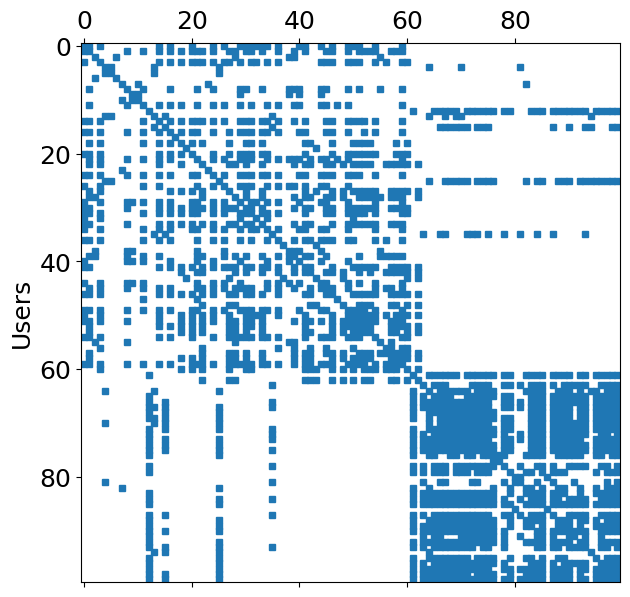

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      2.000000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=5.01e-04 nnz(S)/p=8.93e+01
* iter=1 time=2.73e-03 obj=7.01e+01 |delta(obj)|/obj=4.26e-01 nnz(X,L,W)/p=[8.93e+01 4.92e+01 1.00e+00] lns_iter=7 
* iter=2 time=4.63e-03 obj=6.63e+01 |delta(obj)|/obj=5.72e-02 nnz(X,L,W)/p=[8.93e+01 4.92e+01 9.41e+01] lns_iter=10 
* iter=3 time=2.67e-02 obj=6.01e+01 |delta(obj)|/o

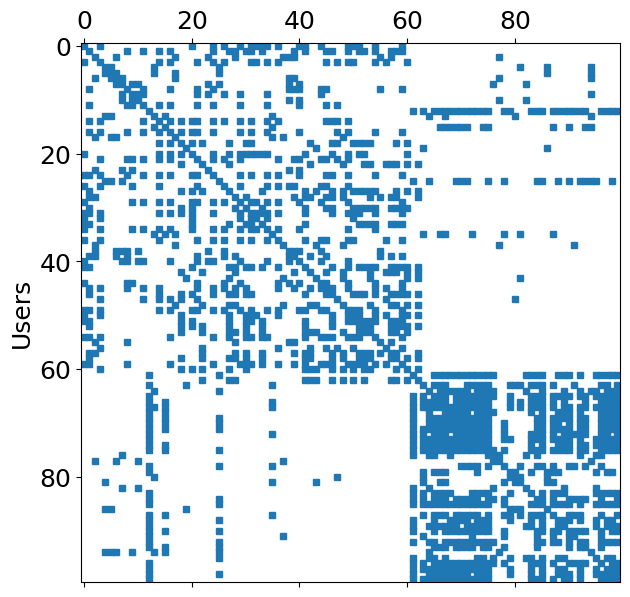

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=4.51e-04 nnz(S)/p=9.44e+01
* iter=1 time=2.67e-03 obj=7.61e+01 |delta(obj)|/obj=3.14e-01 nnz(X,L,W)/p=[9.44e+01 5.00e+01 1.00e+00] lns_iter=8 
* iter=2 time=4.44e-03 obj=5.98e+01 |delta(obj)|/obj=2.73e-01 nnz(X,L,W)/p=[9.44e+01 5.00e+01 9.15e+01] lns_iter=9 
* iter=3 time=2.84e-02 obj=4.32e+01 |delta(obj)|/ob

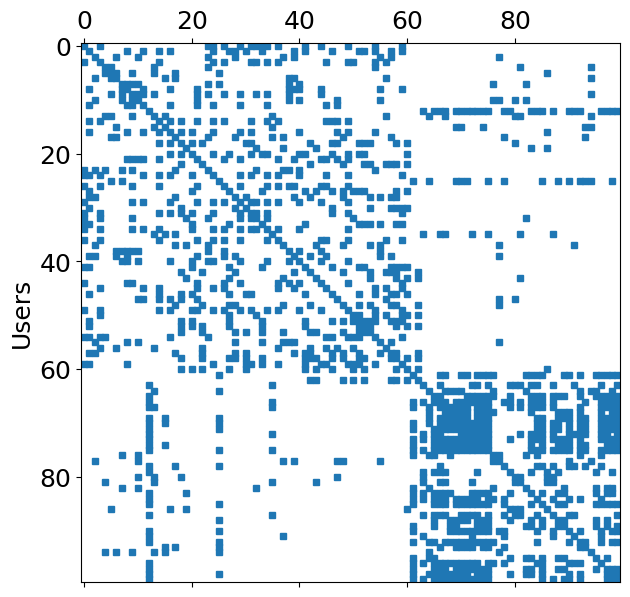

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.000000e-02 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=5.10e-04 nnz(S)/p=9.48e+01
* iter=1 time=2.80e-03 obj=7.42e+01 |delta(obj)|/obj=3.48e-01 nnz(X,L,W)/p=[9.48e+01 5.00e+01 1.00e+00] lns_iter=8 
* iter=2 time=4.48e-03 obj=5.74e+01 |delta(obj)|/obj=2.92e-01 nnz(X,L,W)/p=[9.48e+01 5.00e+01 9.17e+01] lns_iter=9 
* iter=3 time=2.86e-02 obj=4.14e+01 |delta(obj)|/ob

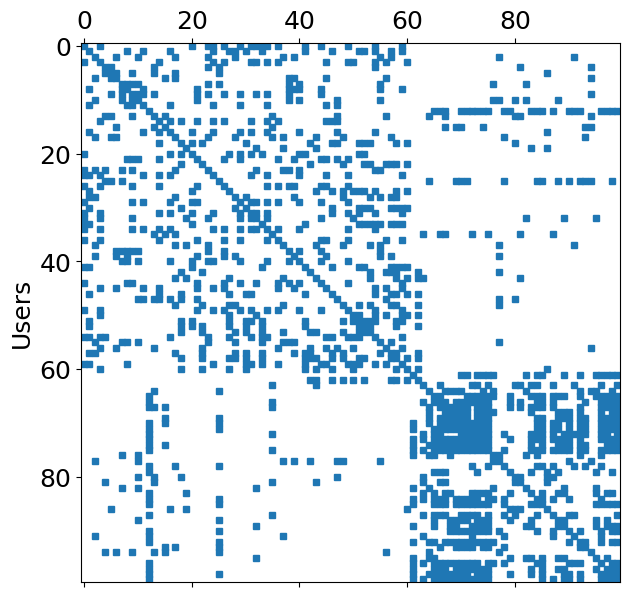

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      5.000000e-02 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=5.83e-04 nnz(S)/p=9.68e+01
* iter=1 time=3.00e-03 obj=6.63e+01 |delta(obj)|/obj=5.07e-01 nnz(X,L,W)/p=[9.68e+01 5.00e+01 1.00e+00] lns_iter=8 
* iter=2 time=4.69e-03 obj=4.78e+01 |delta(obj)|/obj=3.87e-01 nnz(X,L,W)/p=[9.68e+01 5.00e+01 9.20e+01] lns_iter=9 
* iter=3 time=2.93e-02 obj=3.28e+01 |delta(obj)|/ob

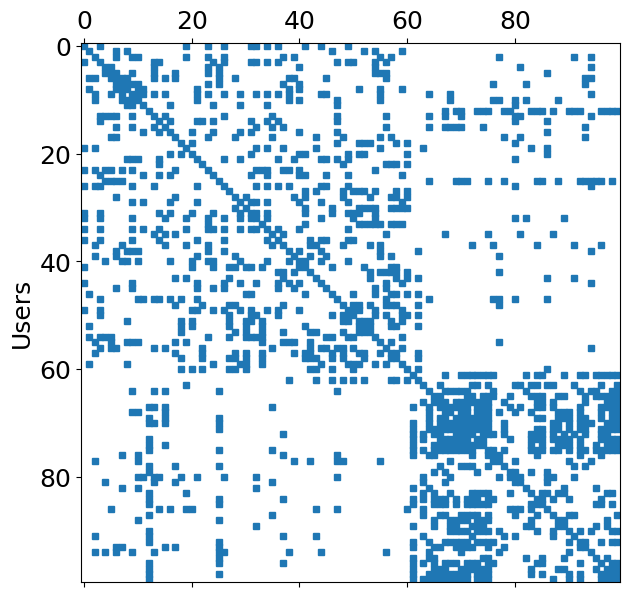

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e-02 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=5.79e-04 nnz(S)/p=9.94e+01
* iter=1 time=2.81e-03 obj=5.83e+01 |delta(obj)|/obj=7.16e-01 nnz(X,L,W)/p=[9.94e+01 5.00e+01 1.00e+00] lns_iter=8 
* iter=2 time=4.69e-03 obj=3.79e+01 |delta(obj)|/obj=5.36e-01 nnz(X,L,W)/p=[9.94e+01 5.00e+01 9.30e+01] lns_iter=9 
* iter=3 time=3.04e-02 obj=2.43e+01 |delta(obj)|/ob

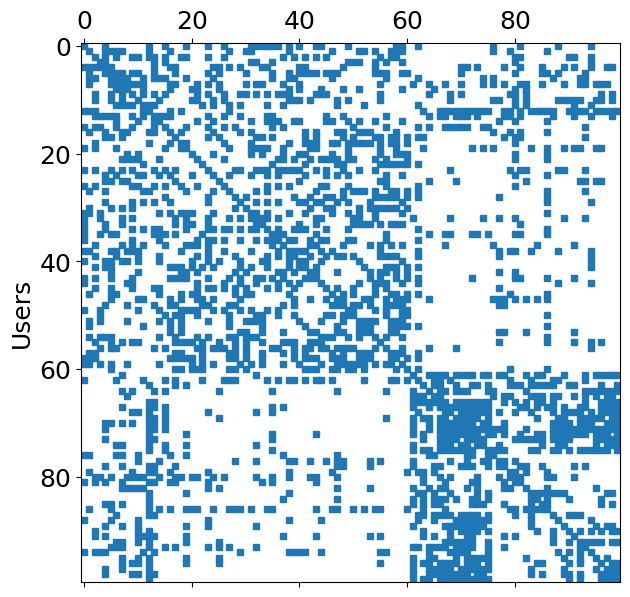

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.000000e-03 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=4.38e-04 nnz(S)/p=9.95e+01
* iter=1 time=2.73e-03 obj=5.81e+01 |delta(obj)|/obj=7.22e-01 nnz(X,L,W)/p=[9.95e+01 5.00e+01 1.00e+00] lns_iter=8 
* iter=2 time=4.82e-03 obj=3.77e+01 |delta(obj)|/obj=5.40e-01 nnz(X,L,W)/p=[9.95e+01 5.00e+01 9.30e+01] lns_iter=9 
* iter=3 time=3.00e-02 obj=2.39e+01 |delta(obj)|/ob

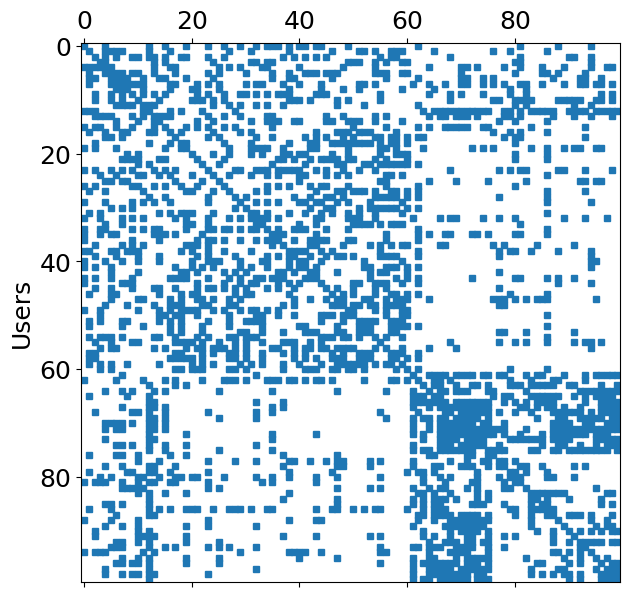

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      5.000000e-03 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=4.11e-04 nnz(S)/p=9.97e+01
* iter=1 time=2.59e-03 obj=5.72e+01 |delta(obj)|/obj=7.47e-01 nnz(X,L,W)/p=[9.97e+01 5.00e+01 1.00e+00] lns_iter=8 
* iter=2 time=5.08e-03 obj=3.67e+01 |delta(obj)|/obj=5.60e-01 nnz(X,L,W)/p=[9.97e+01 5.00e+01 9.30e+01] lns_iter=9 
* iter=3 time=2.98e-02 obj=2.32e+01 |delta(obj)|/ob

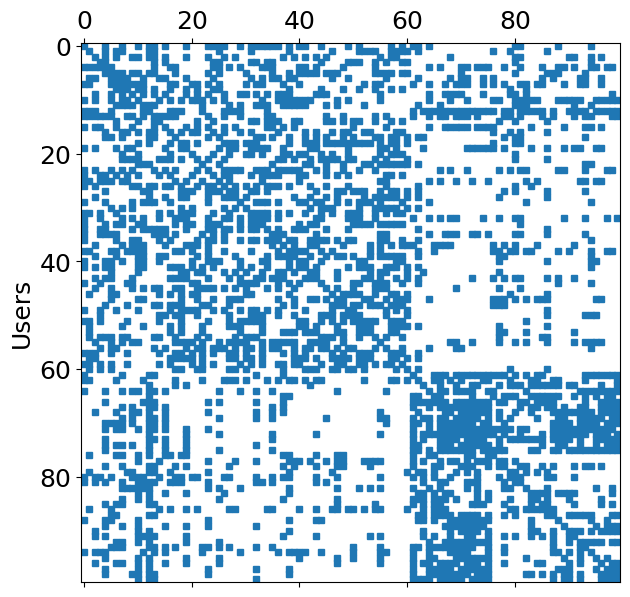

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e-03 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=4.17e-04 nnz(S)/p=1.00e+02
* iter=1 time=2.69e-03 obj=5.64e+01 |delta(obj)|/obj=7.72e-01 nnz(X,L,W)/p=[1.00e+02 5.00e+01 1.00e+00] lns_iter=8 
* iter=2 time=4.87e-03 obj=3.57e+01 |delta(obj)|/obj=5.81e-01 nnz(X,L,W)/p=[1.00e+02 5.00e+01 9.31e+01] lns_iter=9 
* iter=3 time=3.01e-02 obj=2.22e+01 |delta(obj)|/ob

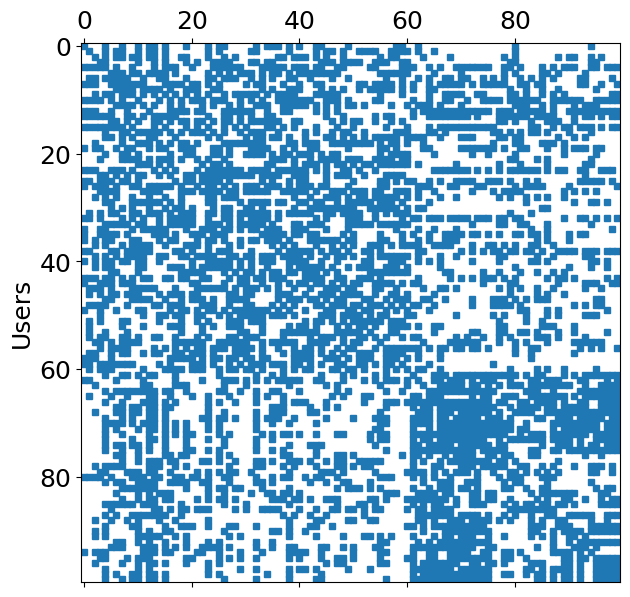

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e-04 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=4.14e-04 nnz(S)/p=1.00e+02
* iter=1 time=5.36e-03 obj=5.62e+01 |delta(obj)|/obj=7.78e-01 nnz(X,L,W)/p=[1.00e+02 5.00e+01 1.00e+00] lns_iter=8 
* iter=2 time=2.36e-02 obj=3.55e+01 |delta(obj)|/obj=5.86e-01 nnz(X,L,W)/p=[1.00e+02 5.00e+01 9.31e+01] lns_iter=9 
* iter=3 time=3.05e-02 obj=2.20e+01 |delta(obj)|/ob

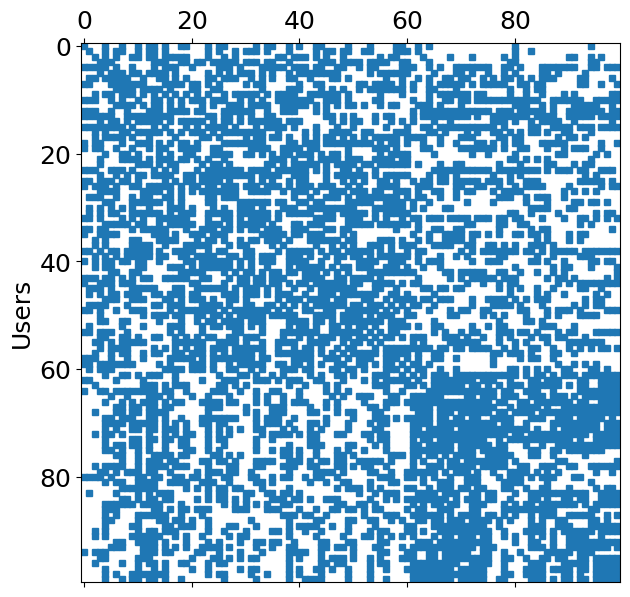

In [32]:
norm_dict = {}

data_nnz = []
data_nnzr = []
data_time = []

for rho in l:
    norm_dict[rho], end_time = squic_fit(Y_new, lambda_val=rho, eta=rho * 0.1)
    end_time = round(end_time, 2)
    print(f"required time: {end_time}")

    nnz, nnz_r = nnz_fit(norm_dict[rho], ROWS)
    print(f"nnz = {nnz} per rows = {nnz_r}")

    sparsity_pattern(norm_dict[rho])

    data_nnz.append(nnz)
    data_nnzr.append(nnz_r)
    data_time.append(end_time)

data_fit_norm = [
    ["NNZ"] + data_nnz,
    ["NNZ/Row"] + data_nnzr,
    ["Time (s)"] + data_time
]


## Table

In [33]:
def table(data, title, l):
    table = tabulate(
        data,
        headers=[title] + l,
        tablefmt="fancy_grid",
        numalign="center",
        stralign="center"
    )
    return table

In [34]:
# Print table 1
print(table(data_df, "SQUIC NORM", l))

print(table(data_fit_norm, "SQUIC FIT NORM", l))

╒══════════════╤═══════╤═══════╤═══════╤═══════╤════════╤════════╤════════╤═════════╤═════════╤═════════╤══════════╕
│  SQUIC NORM  │  0.9  │  0.5  │  0.2  │  0.1  │  0.09  │  0.05  │  0.01  │  0.009  │  0.005  │  0.001  │  0.0001  │
╞══════════════╪═══════╪═══════╪═══════╪═══════╪════════╪════════╪════════╪═════════╪═════════╪═════════╪══════════╡
│     NNZ      │ 2774  │ 4372  │ 3574  │ 3088  │  3120  │  3140  │  4744  │  4938   │  5822   │  8614   │   9992   │
├──────────────┼───────┼───────┼───────┼───────┼────────┼────────┼────────┼─────────┼─────────┼─────────┼──────────┤
│   NNZ/Row    │ 27.74 │ 43.72 │ 35.74 │ 30.88 │  31.2  │  31.4  │ 47.44  │  49.38  │  58.22  │  86.14  │  99.92   │
├──────────────┼───────┼───────┼───────┼───────┼────────┼────────┼────────┼─────────┼─────────┼─────────┼──────────┤
│   Time (s)   │ 0.05  │  0.3  │ 0.25  │  1.1  │  1.01  │  1.56  │  7.98  │  8.86   │  13.44  │  23.96  │  23.95   │
╘══════════════╧═══════╧═══════╧═══════╧═══════╧════════╧═══════